Imports & globale Einstellungen

In [2]:
import kagglehub
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler

Dataset laden

In [3]:
path = kagglehub.dataset_download("harlfoxem/housesalesprediction")
print("Path to dataset files:", path)

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
df_original = pd.read_csv(os.path.join(path, csv_file))
print(f"Dataset geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")
print(f"Dataset geladen: {df_original.shape[0]} Zeilen, {df_original.shape[1]} Spalten")

Path to dataset files: C:\Users\joshu\.cache\kagglehub\datasets\harlfoxem\housesalesprediction\versions\1
Dataset geladen: 21613 Zeilen, 21 Spalten
Dataset geladen: 21613 Zeilen, 21 Spalten


Boxplots aller Features (außer id, date, zipcode, long, lat)

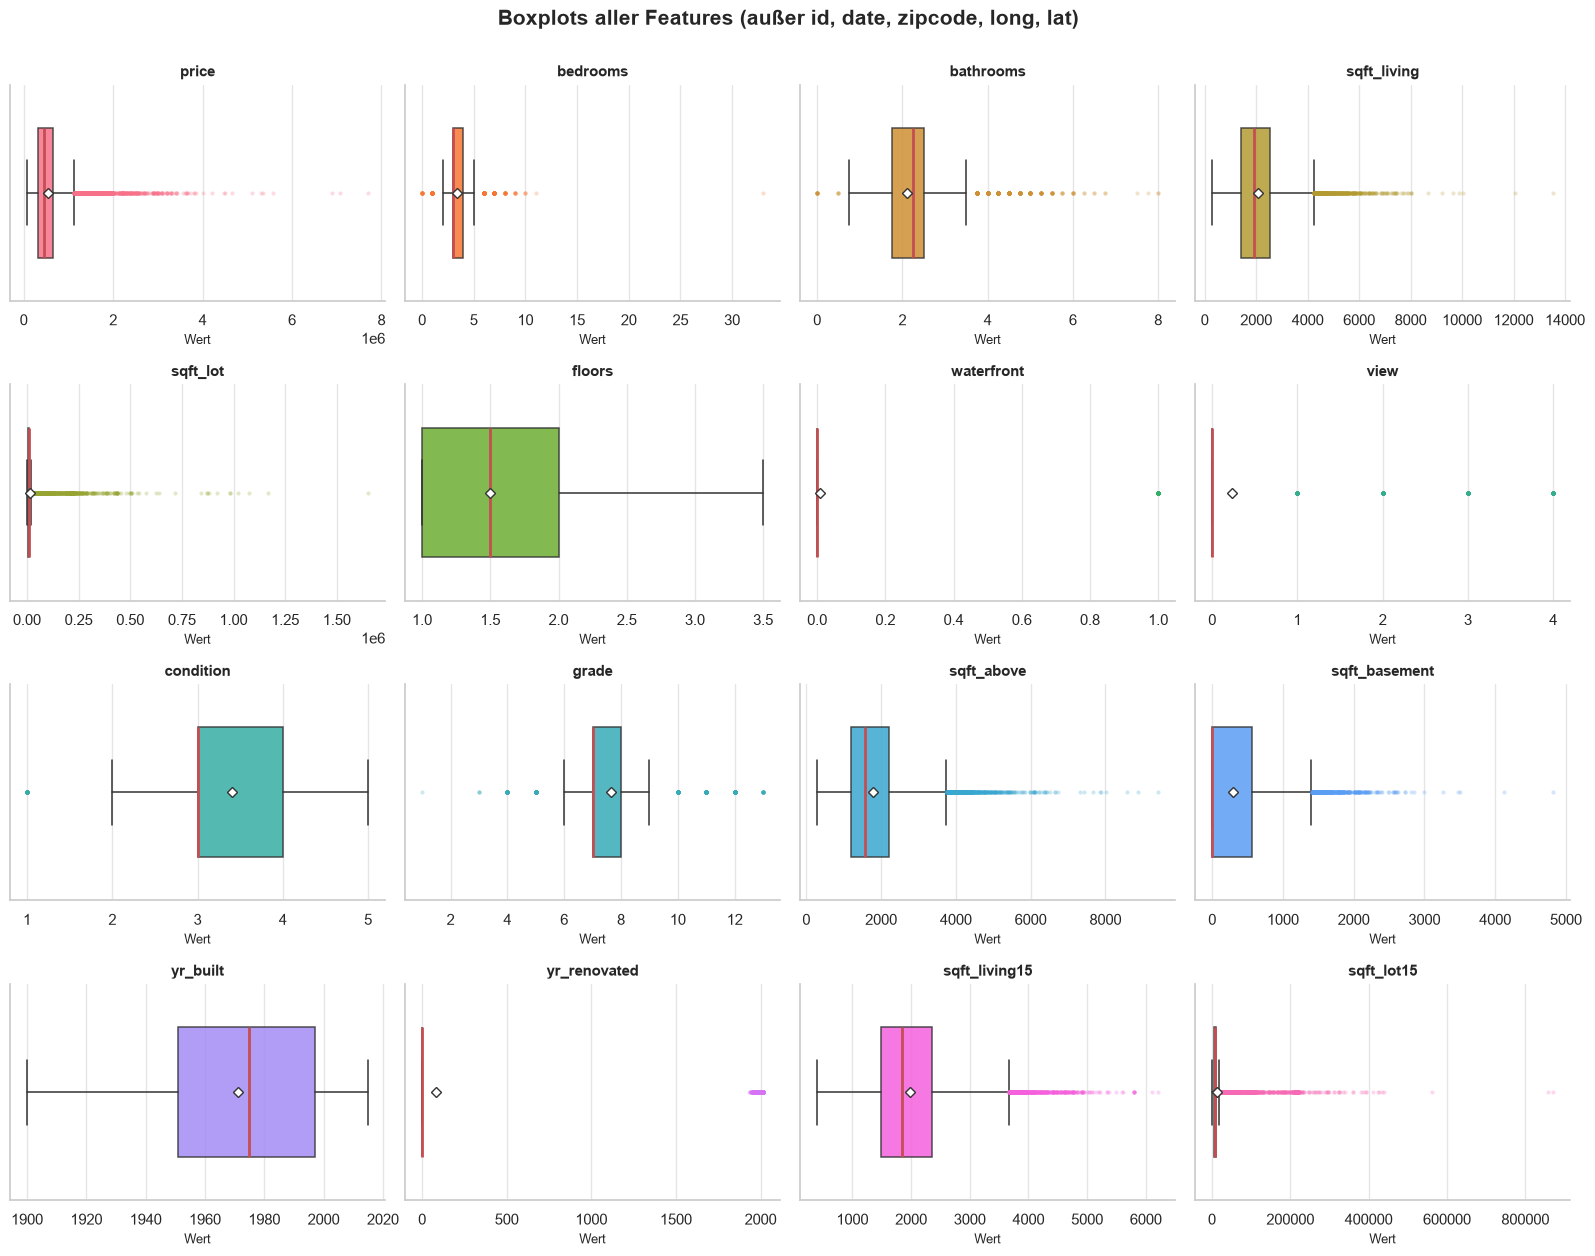

In [4]:
# Boxplots ALLER numerischen Features außer id, date, zipcode, long, lat
df_full = pd.read_csv(os.path.join(path, csv_file))
exclude = ["id", "date", "zipcode", "long", "lat"]
plot_features = [c for c in df_full.columns
                 if c not in exclude and pd.api.types.is_numeric_dtype(df_full[c])]

sns.set_theme(style="whitegrid")
palette = sns.color_palette("husl", len(plot_features))

ncols = 4
nrows = int(np.ceil(len(plot_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
axes = axes.ravel()

for ax, feat, color in zip(axes, plot_features, palette):
    ax.boxplot(
        df_full[feat],
        orientation="horizontal",
        patch_artist=True,
        widths=0.6,
        showmeans=True,
        boxprops=dict(facecolor=color, edgecolor="#333333", alpha=.85, linewidth=1.1),
        medianprops=dict(color="#C44E52", linewidth=2),
        meanprops=dict(marker="D", markerfacecolor="white",
                       markeredgecolor="#333333", markersize=5),
        whiskerprops=dict(color="#333333", linewidth=1.1),
        capprops=dict(color="#333333", linewidth=1.1),
        flierprops=dict(marker="o", markerfacecolor=color, markeredgecolor="none",
                        markersize=3, alpha=.25),
    )
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("Wert", fontsize=9)
    ax.set_yticks([])
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right"]].set_visible(False)

# ungenutzte Achsen ausblenden
for ax in axes[len(plot_features):]:
    ax.set_visible(False)

fig.suptitle("Boxplots aller Features (außer id, date, zipcode, long, lat)",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


Histogramme aller Features (außer id, date, zipcode, long, lat)

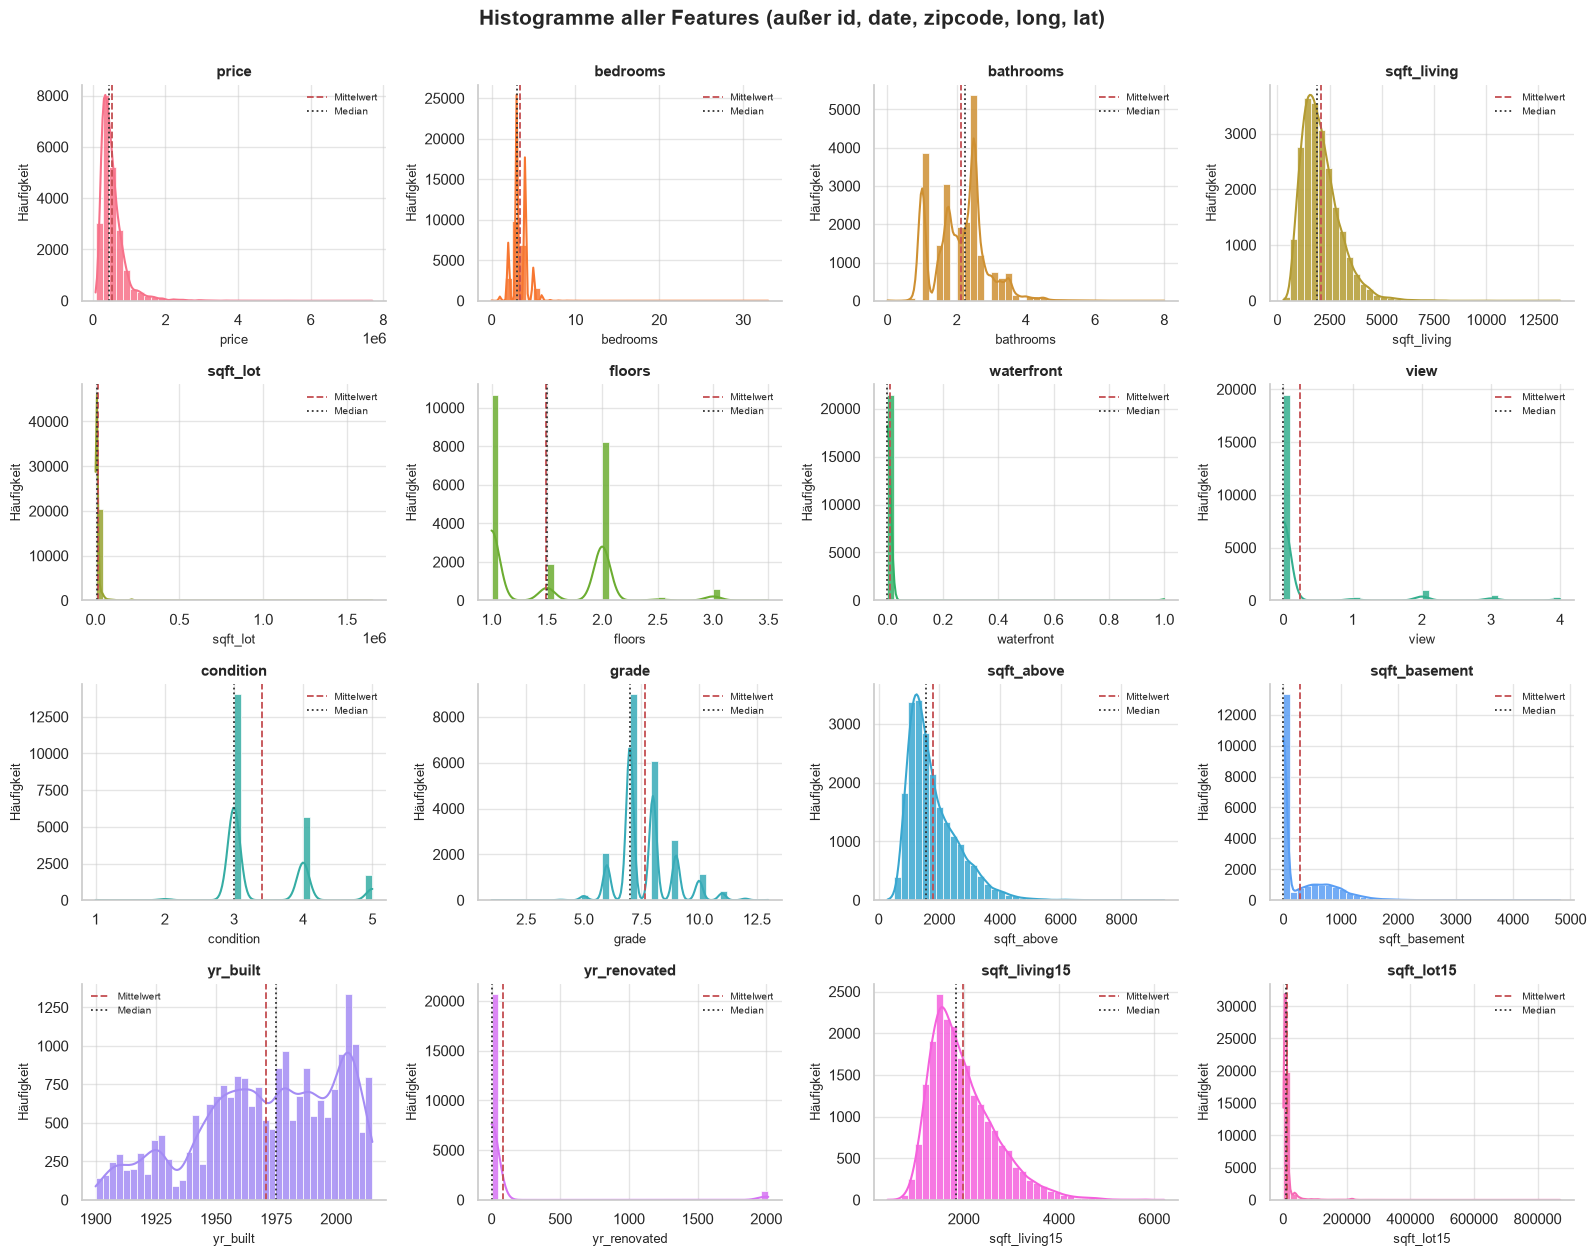

In [5]:
# Histogramme ALLER numerischen Features außer id, date, zipcode, long, lat
df_full = pd.read_csv(os.path.join(path, csv_file))
exclude = ["id", "date", "zipcode", "long", "lat"]
plot_features = [c for c in df_full.columns
                 if c not in exclude and pd.api.types.is_numeric_dtype(df_full[c])]

sns.set_theme(style="whitegrid")
palette = sns.color_palette("husl", len(plot_features))

ncols = 4
nrows = int(np.ceil(len(plot_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
axes = axes.ravel()

for ax, feat, color in zip(axes, plot_features, palette):
    sns.histplot(df_full[feat], bins=40, kde=True, color=color,
                 edgecolor="white", linewidth=.5, alpha=.85, ax=ax)
    ax.axvline(df_full[feat].mean(), color="#C44E52", linestyle="--",
               linewidth=1.3, label="Mittelwert")
    ax.axvline(df_full[feat].median(), color="#333333", linestyle=":",
               linewidth=1.3, label="Median")
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel("Häufigkeit", fontsize=9)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

# ungenutzte Achsen ausblenden
for ax in axes[len(plot_features):]:
    ax.set_visible(False)

fig.suptitle("Histogramme aller Features (außer id, date, zipcode, long, lat)",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


0 Badezimmer

In [6]:
df.loc[df["bathrooms"] == 0]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
875,6306400140,20140612T000000,1095000.0,0,0.0,3064,4764,3.5,0,2,...,7,3064,0,1990,0,98102,47.6362,-122.322,2360,4000
1149,3421079032,20150217T000000,75000.0,1,0.0,670,43377,1.0,0,0,...,3,670,0,1966,0,98022,47.2638,-121.906,1160,42882
3119,3918400017,20150205T000000,380000.0,0,0.0,1470,979,3.0,0,2,...,8,1470,0,2006,0,98133,47.7145,-122.356,1470,1399
5832,5702500050,20141104T000000,280000.0,1,0.0,600,24501,1.0,0,0,...,3,600,0,1950,0,98045,47.5316,-121.749,990,22549
6994,2954400190,20140624T000000,1295650.0,0,0.0,4810,28008,2.0,0,0,...,12,4810,0,1990,0,98053,47.6642,-122.069,4740,35061
9773,3374500520,20150429T000000,355000.0,0,0.0,2460,8049,2.0,0,0,...,8,2460,0,1990,0,98031,47.4095,-122.168,2520,8050
9854,7849202190,20141223T000000,235000.0,0,0.0,1470,4800,2.0,0,0,...,7,1470,0,1996,0,98065,47.5265,-121.828,1060,7200
10481,203100435,20140918T000000,484000.0,1,0.0,690,23244,1.0,0,0,...,7,690,0,1948,0,98053,47.6429,-121.955,1690,19290
14423,9543000205,20150413T000000,139950.0,0,0.0,844,4269,1.0,0,0,...,7,844,0,1913,0,98001,47.2781,-122.250,1380,9600
19452,3980300371,20140926T000000,142000.0,0,0.0,290,20875,1.0,0,0,...,1,290,0,1963,0,98024,47.5308,-121.888,1620,22850


In [7]:
# Cleaning: Häuser mit 0 Badezimmern entfernen (fehlerhafte Datensätze)
print(f"Vorher: {len(df)} Zeilen")
df = df[df["bathrooms"] > 0].reset_index(drop=True)
print(f"Nachher: {len(df)} Zeilen "
      f"({(df['bathrooms'] == 0).sum()} mit 0 Badezimmern verbleibend)")


Vorher: 21613 Zeilen
Nachher: 21603 Zeilen (0 mit 0 Badezimmern verbleibend)


33 Badezimmer

In [8]:
df.loc[df["bedrooms"] == 33]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15861,2402100895,20140625T000000,640000.0,33,1.75,1620,6000,1.0,0,0,...,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


In [9]:
# Cleaning: offensichtlicher Tippfehler (33 Schlafzimmer -> 3) korrigieren
print("Vorher:", df.loc[df["bedrooms"] == 33, "bedrooms"].values)
df.loc[df["bedrooms"] == 33, "bedrooms"] = 3
print("Zeilen mit 33 Schlafzimmern danach:", (df["bedrooms"] == 33).sum())


Vorher: [33]
Zeilen mit 33 Schlafzimmern danach: 0


In [10]:
# Cleaning: Häuser mit 0 Schlafzimmern entfernen (fehlerhafte Datensätze)
print(f"Vorher: {len(df)} Zeilen")
df = df[df["bedrooms"] > 0].reset_index(drop=True)
print(f"Nachher: {len(df)} Zeilen "
      f"({(df['bedrooms'] == 0).sum()} mit 0 Schlafzimmern verbleibend)")


Vorher: 21603 Zeilen
Nachher: 21597 Zeilen (0 mit 0 Schlafzimmern verbleibend)


Duplikate prüfen

In [11]:
# 1. Komplett identische Zeilen (alle Spalten gleich, inkl. id/date)
print("Komplett identische Zeilen:", df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))


Komplett identische Zeilen: 0


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15


In [12]:
# 2. Gleiches Haus, ohne id/date (dieselbe Immobilie ggf. doppelt erfasst)
cols = df.columns.difference(["id", "date"])
print("Doppelte Häuser (ohne id/date):", df.duplicated(subset=cols).sum())
df[df.duplicated(subset=cols, keep=False)].sort_values(by=list(cols))


Doppelte Häuser (ohne id/date): 5


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
3946,1825069031,20140814T000000,550000.0,4,1.75,2410,8447,2.0,0,3,...,8,2060,350,1936,1980,98074,47.6499,-122.088,2520,14789
3947,1825069031,20141016T000000,550000.0,4,1.75,2410,8447,2.0,0,3,...,8,2060,350,1936,1980,98074,47.6499,-122.088,2520,14789
547,7899800860,20150319T000000,259950.0,2,2.00,1070,649,2.0,0,0,...,9,720,350,2008,0,98106,47.5213,-122.357,1070,928
4348,7899800864,20150305T000000,259950.0,2,2.00,1070,649,2.0,0,0,...,9,720,350,2008,0,98106,47.5213,-122.357,1070,928
19620,9385200041,20150304T000000,529500.0,3,2.25,1410,905,3.0,0,0,...,9,1410,0,2014,0,98116,47.5818,-122.402,1510,1352
20508,9385200042,20150318T000000,529500.0,3,2.25,1410,905,3.0,0,0,...,9,1410,0,2014,0,98116,47.5818,-122.402,1510,1352
20037,8648900110,20140505T000000,555000.0,3,2.50,1940,3211,2.0,0,0,...,8,1940,0,2009,0,98027,47.5644,-122.093,1880,3078
20038,8648900110,20140826T000000,555000.0,3,2.50,1940,3211,2.0,0,0,...,8,1940,0,2009,0,98027,47.5644,-122.093,1880,3078
14968,6308000010,20141208T000000,585000.0,3,2.50,2290,5089,2.0,0,0,...,9,2290,0,2001,0,98006,47.5443,-122.172,2290,7984
14969,6308000010,20150423T000000,585000.0,3,2.50,2290,5089,2.0,0,0,...,9,2290,0,2001,0,98006,47.5443,-122.172,2290,7984


Wiederverkäufe reduzieren

Pro Haus (`id`) nur den **jüngsten** Verkauf behalten. Das `date`-Format `YYYYMMDDT...` sortiert chronologisch korrekt, `keep="last"` behält nach aufsteigender Sortierung den neuesten Verkauf.

In [13]:
# Wiederverkäufe: pro id nur den jüngsten Verkauf behalten
n_before = len(df)
df = (df.sort_values("date")
        .drop_duplicates(subset="id", keep="last")
        .reset_index(drop=True))
print(f"Vorher: {n_before} Zeilen -> Nachher: {len(df)} Zeilen "
      f"({n_before - len(df)} Wiederverkäufe entfernt)")
print("Verbleibende doppelte ids:", df["id"].duplicated().sum())


Vorher: 21597 Zeilen -> Nachher: 21420 Zeilen (177 Wiederverkäufe entfernt)
Verbleibende doppelte ids: 0


Boxplots & Histogramme NACH dem Cleaning

Dieselben Features wie oben, aber auf dem bereinigten `df` (0 Badezimmer entfernt, 33 → 3 Schlafzimmer korrigiert, 0 Schlafzimmer entfernt) – zum Vorher/Nachher-Vergleich.

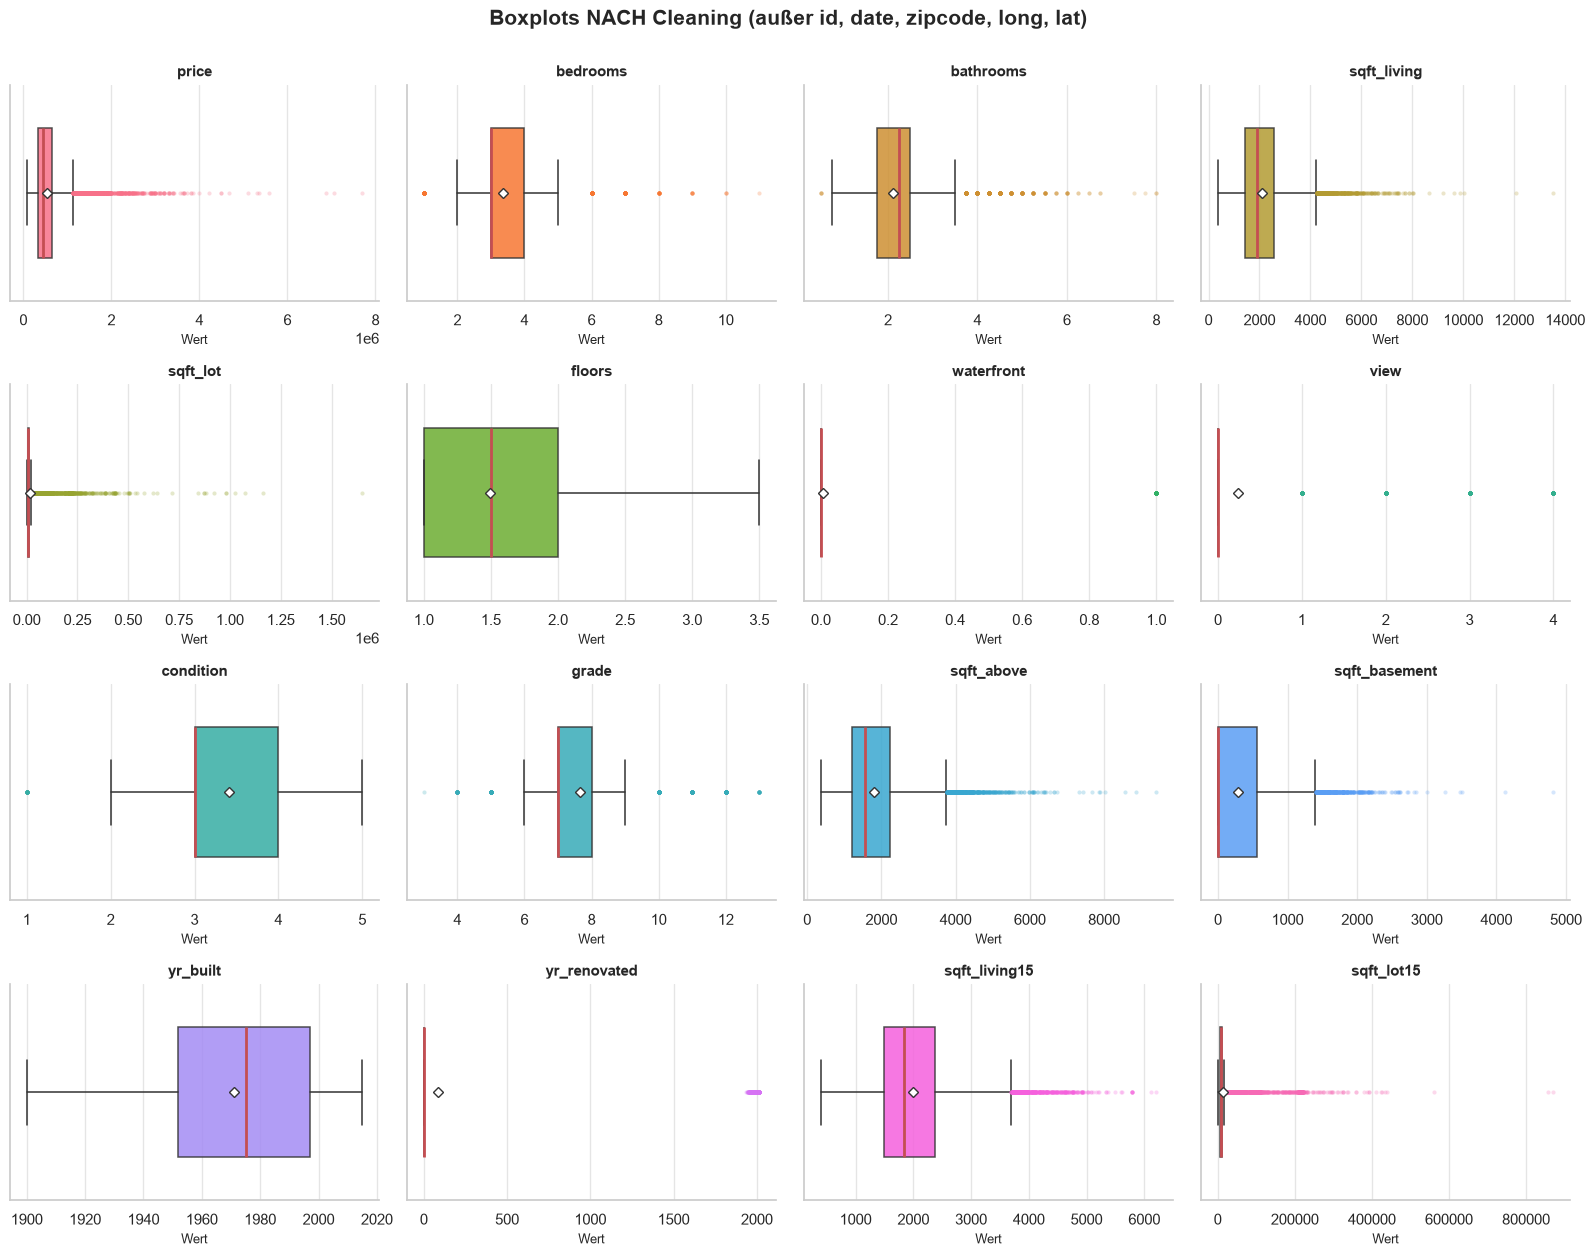

In [14]:
# Boxplots NACH dem Cleaning – auf dem bereinigten df
exclude = ["id", "date", "zipcode", "long", "lat"]
plot_features = [c for c in df.columns
                 if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

sns.set_theme(style="whitegrid")
palette = sns.color_palette("husl", len(plot_features))

ncols = 4
nrows = int(np.ceil(len(plot_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
axes = axes.ravel()

for ax, feat, color in zip(axes, plot_features, palette):
    ax.boxplot(
        df[feat],
        orientation="horizontal",
        patch_artist=True,
        widths=0.6,
        showmeans=True,
        boxprops=dict(facecolor=color, edgecolor="#333333", alpha=.85, linewidth=1.1),
        medianprops=dict(color="#C44E52", linewidth=2),
        meanprops=dict(marker="D", markerfacecolor="white",
                       markeredgecolor="#333333", markersize=5),
        whiskerprops=dict(color="#333333", linewidth=1.1),
        capprops=dict(color="#333333", linewidth=1.1),
        flierprops=dict(marker="o", markerfacecolor=color, markeredgecolor="none",
                        markersize=3, alpha=.25),
    )
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("Wert", fontsize=9)
    ax.set_yticks([])
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(plot_features):]:
    ax.set_visible(False)

fig.suptitle("Boxplots NACH Cleaning (außer id, date, zipcode, long, lat)",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


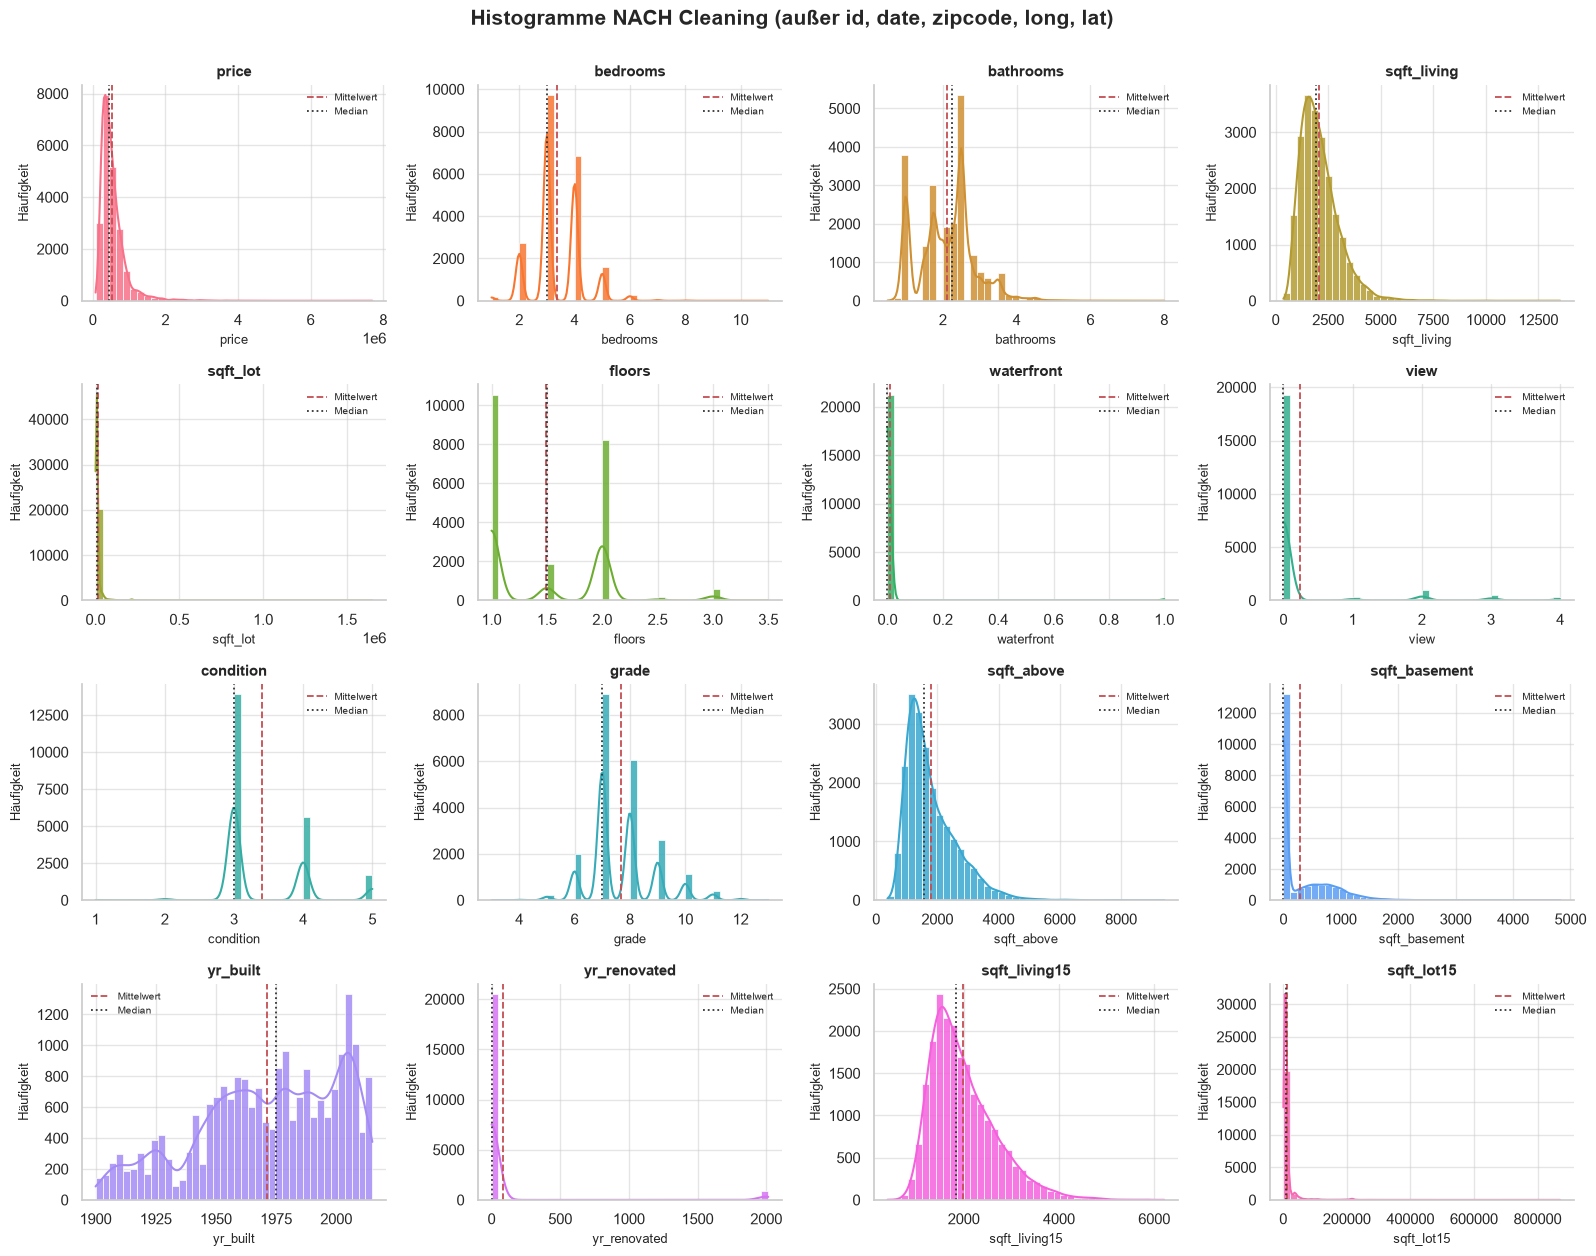

In [15]:
# Histogramme NACH dem Cleaning – auf dem bereinigten df
exclude = ["id", "date", "zipcode", "long", "lat"]
plot_features = [c for c in df.columns
                 if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

sns.set_theme(style="whitegrid")
palette = sns.color_palette("husl", len(plot_features))

ncols = 4
nrows = int(np.ceil(len(plot_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
axes = axes.ravel()

for ax, feat, color in zip(axes, plot_features, palette):
    sns.histplot(df[feat], bins=40, kde=True, color=color,
                 edgecolor="white", linewidth=.5, alpha=.85, ax=ax)
    ax.axvline(df[feat].mean(), color="#C44E52", linestyle="--",
               linewidth=1.3, label="Mittelwert")
    ax.axvline(df[feat].median(), color="#333333", linestyle=":",
               linewidth=1.3, label="Median")
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel("Häufigkeit", fontsize=9)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(plot_features):]:
    ax.set_visible(False)

fig.suptitle("Histogramme NACH Cleaning (außer id, date, zipcode, long, lat)",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


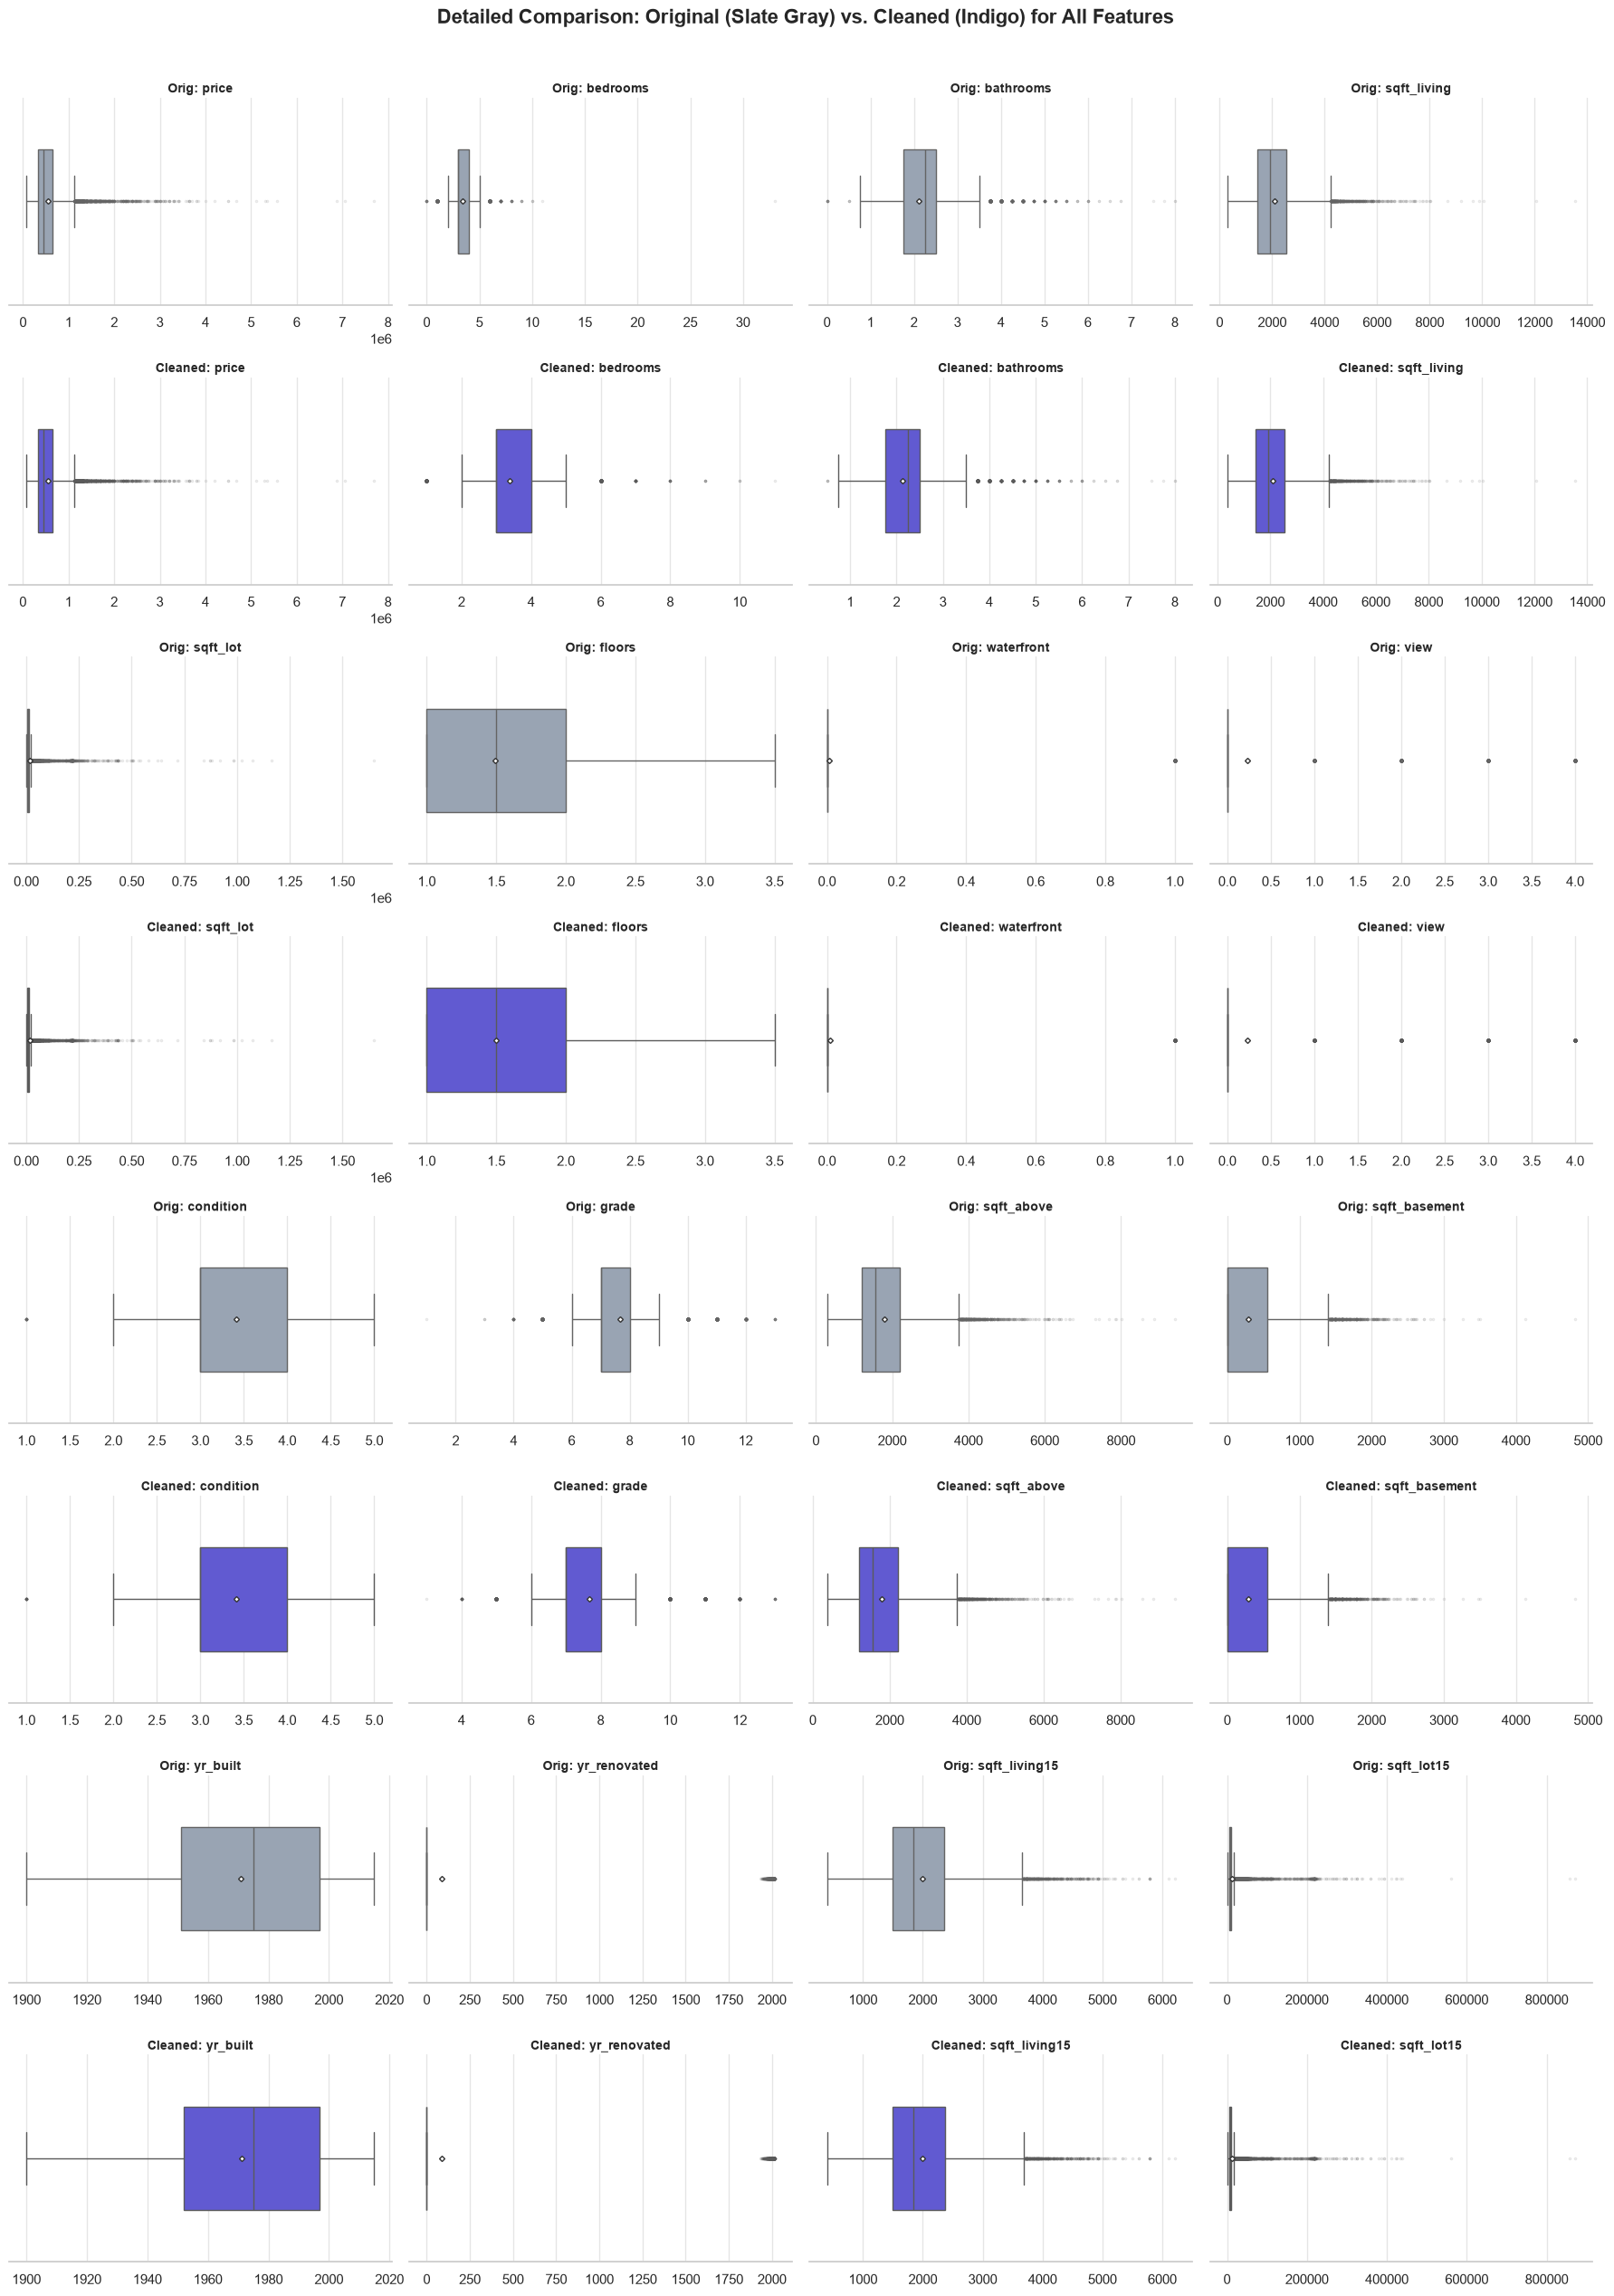

In [16]:
# 1. Identify numeric features to compare
exclude = ["id", "date", "zipcode", "long", "lat"]
plot_features = [c for c in df_original.columns if c not in exclude and pd.api.types.is_numeric_dtype(df_original[c])]
ncols = 4
n_features = len(plot_features)
nrows_feat = int(np.ceil(n_features / ncols))
# We need 2 subplots vertically for each feature row
fig, axes = plt.subplots(nrows_feat * 2, ncols, figsize=(18, 3.2 * nrows_feat * 2))
color_original = "#94A3B8"  # Cool Slate Gray
color_cleaned = "#4F46E5"   # Premium Indigo
# 2. Iterate and plot stacked comparisons
for idx, feat in enumerate(plot_features):
    col = idx % ncols
    row_orig = 2 * (idx // ncols)
    row_clean = row_orig + 1
    
    ax_orig = axes[row_orig, col]
    ax_clean = axes[row_clean, col]
    
    # Plot Original
    sns.boxplot(
        data=df_original,
        x=feat,
        color=color_original,
        ax=ax_orig,
        width=0.5,
        showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333333", markersize=3),
        flierprops=dict(marker="o", markersize=1.5, alpha=0.15)
    )
    ax_orig.set_title(f"Orig: {feat}", fontsize=10, fontweight="bold", pad=4)
    ax_orig.set_xlabel("")
    sns.despine(ax=ax_orig, left=True)
    
    # Plot Cleaned
    sns.boxplot(
        data=df,
        x=feat,
        color=color_cleaned,
        ax=ax_clean,
        width=0.5,
        showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333333", markersize=3),
        flierprops=dict(marker="o", markersize=1.5, alpha=0.15)
    )
    ax_clean.set_title(f"Cleaned: {feat}", fontsize=10, fontweight="bold", pad=4)
    ax_clean.set_xlabel("")
    sns.despine(ax=ax_clean, left=True)
# 3. Hide any unused subplot slots
total_slots = nrows_feat * 2 * ncols
used_slots_orig = [2 * (i // ncols) * ncols + (i % ncols) for i in range(n_features)]
used_slots_clean = [(2 * (i // ncols) + 1) * ncols + (i % ncols) for i in range(n_features)]
used_slots = set(used_slots_orig + used_slots_clean)
for flat_idx in range(total_slots):
    r = flat_idx // ncols
    c = flat_idx % ncols
    if flat_idx not in used_slots:
        axes[r, c].set_visible(False)
fig.suptitle("Detailed Comparison: Original (Slate Gray) vs. Cleaned (Indigo) for All Features", 
             fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

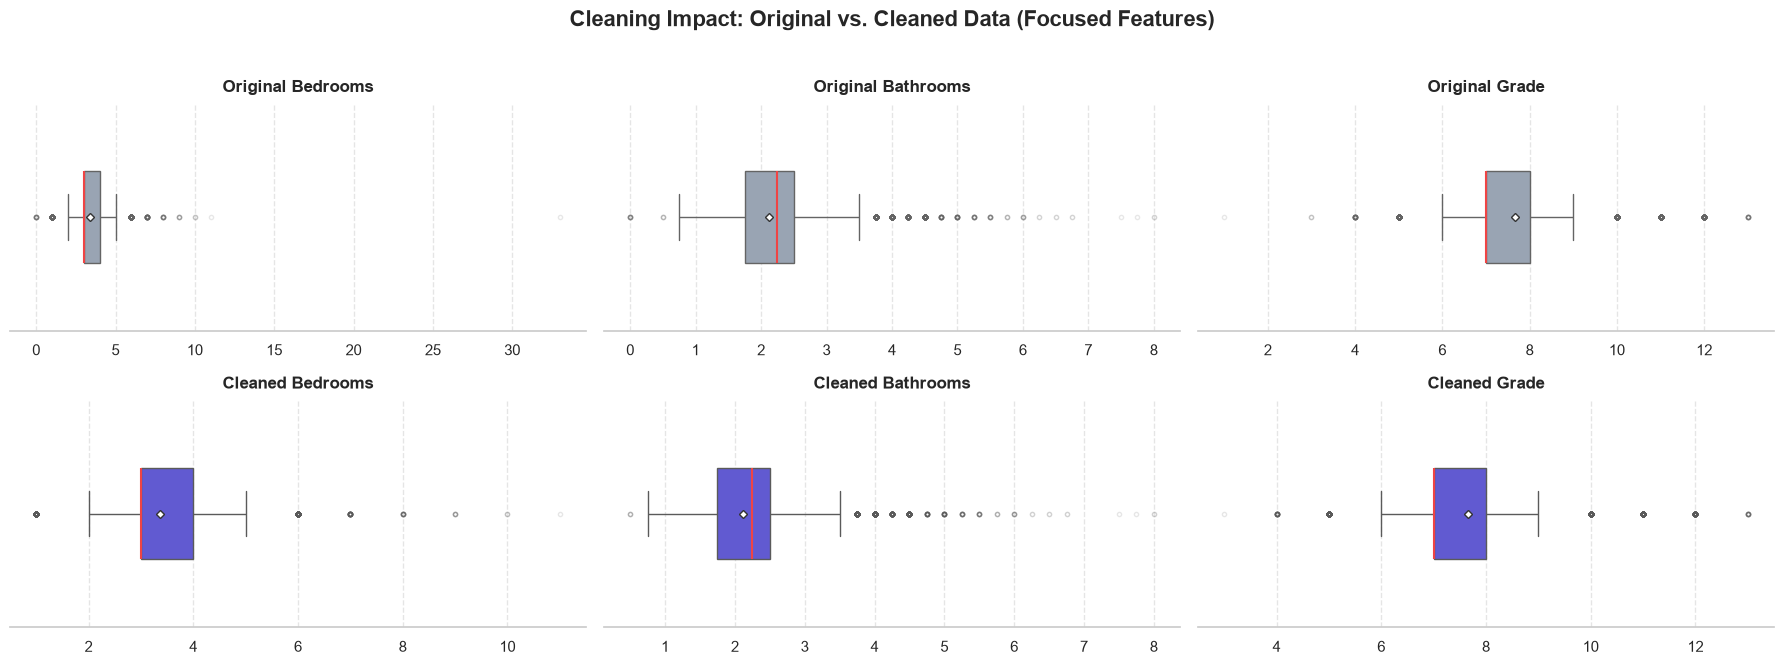

In [17]:
# 1. Focus on the specified key features
focus_features = ["bedrooms", "bathrooms", "grade"]
# 2. Create a 2x4 grid (Row 0: Original, Row 1: Cleaned)
fig, axes = plt.subplots(nrows=2, ncols=len(focus_features), figsize=(18, 6.5))
# Premium color palette: Slate Gray for raw data, Indigo for cleaned data
color_original = "#94A3B8"  
color_cleaned = "#4F46E5"   
# 3. Plot Original Features on the Top Row
for col_idx, feat in enumerate(focus_features):
    ax = axes[0, col_idx]
    sns.boxplot(
        data=df_original,
        x=feat,
        color=color_original,
        ax=ax,
        width=0.4,
        showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333333", markersize=4),
        medianprops=dict(color="#EF4444", linewidth=1.5), # Vibrant Rose-Red median
        flierprops=dict(marker="o", markersize=3, alpha=0.15)
    )
    ax.set_title(f"Original {feat.capitalize()}", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    sns.despine(ax=ax, left=True)
    
    # Custom format for price values (e.g. $1.2M, $500K)
    if feat == "price":
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M" if x >= 1e6 else f"${x*1e-3:.0f}K"))
# 4. Plot Cleaned Features on the Bottom Row
for col_idx, feat in enumerate(focus_features):
    ax = axes[1, col_idx]
    sns.boxplot(
        data=df,
        x=feat,
        color=color_cleaned,
        ax=ax,
        width=0.4,
        showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333333", markersize=4),
        medianprops=dict(color="#EF4444", linewidth=1.5),
        flierprops=dict(marker="o", markersize=3, alpha=0.15)
    )
    ax.set_title(f"Cleaned {feat.capitalize()}", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    sns.despine(ax=ax, left=True)
    
    # Custom format for price values (e.g. $1.2M, $500K)
    if feat == "price":
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M" if x >= 1e6 else f"${x*1e-3:.0f}K"))
fig.suptitle("Cleaning Impact: Original vs. Cleaned Data (Focused Features)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

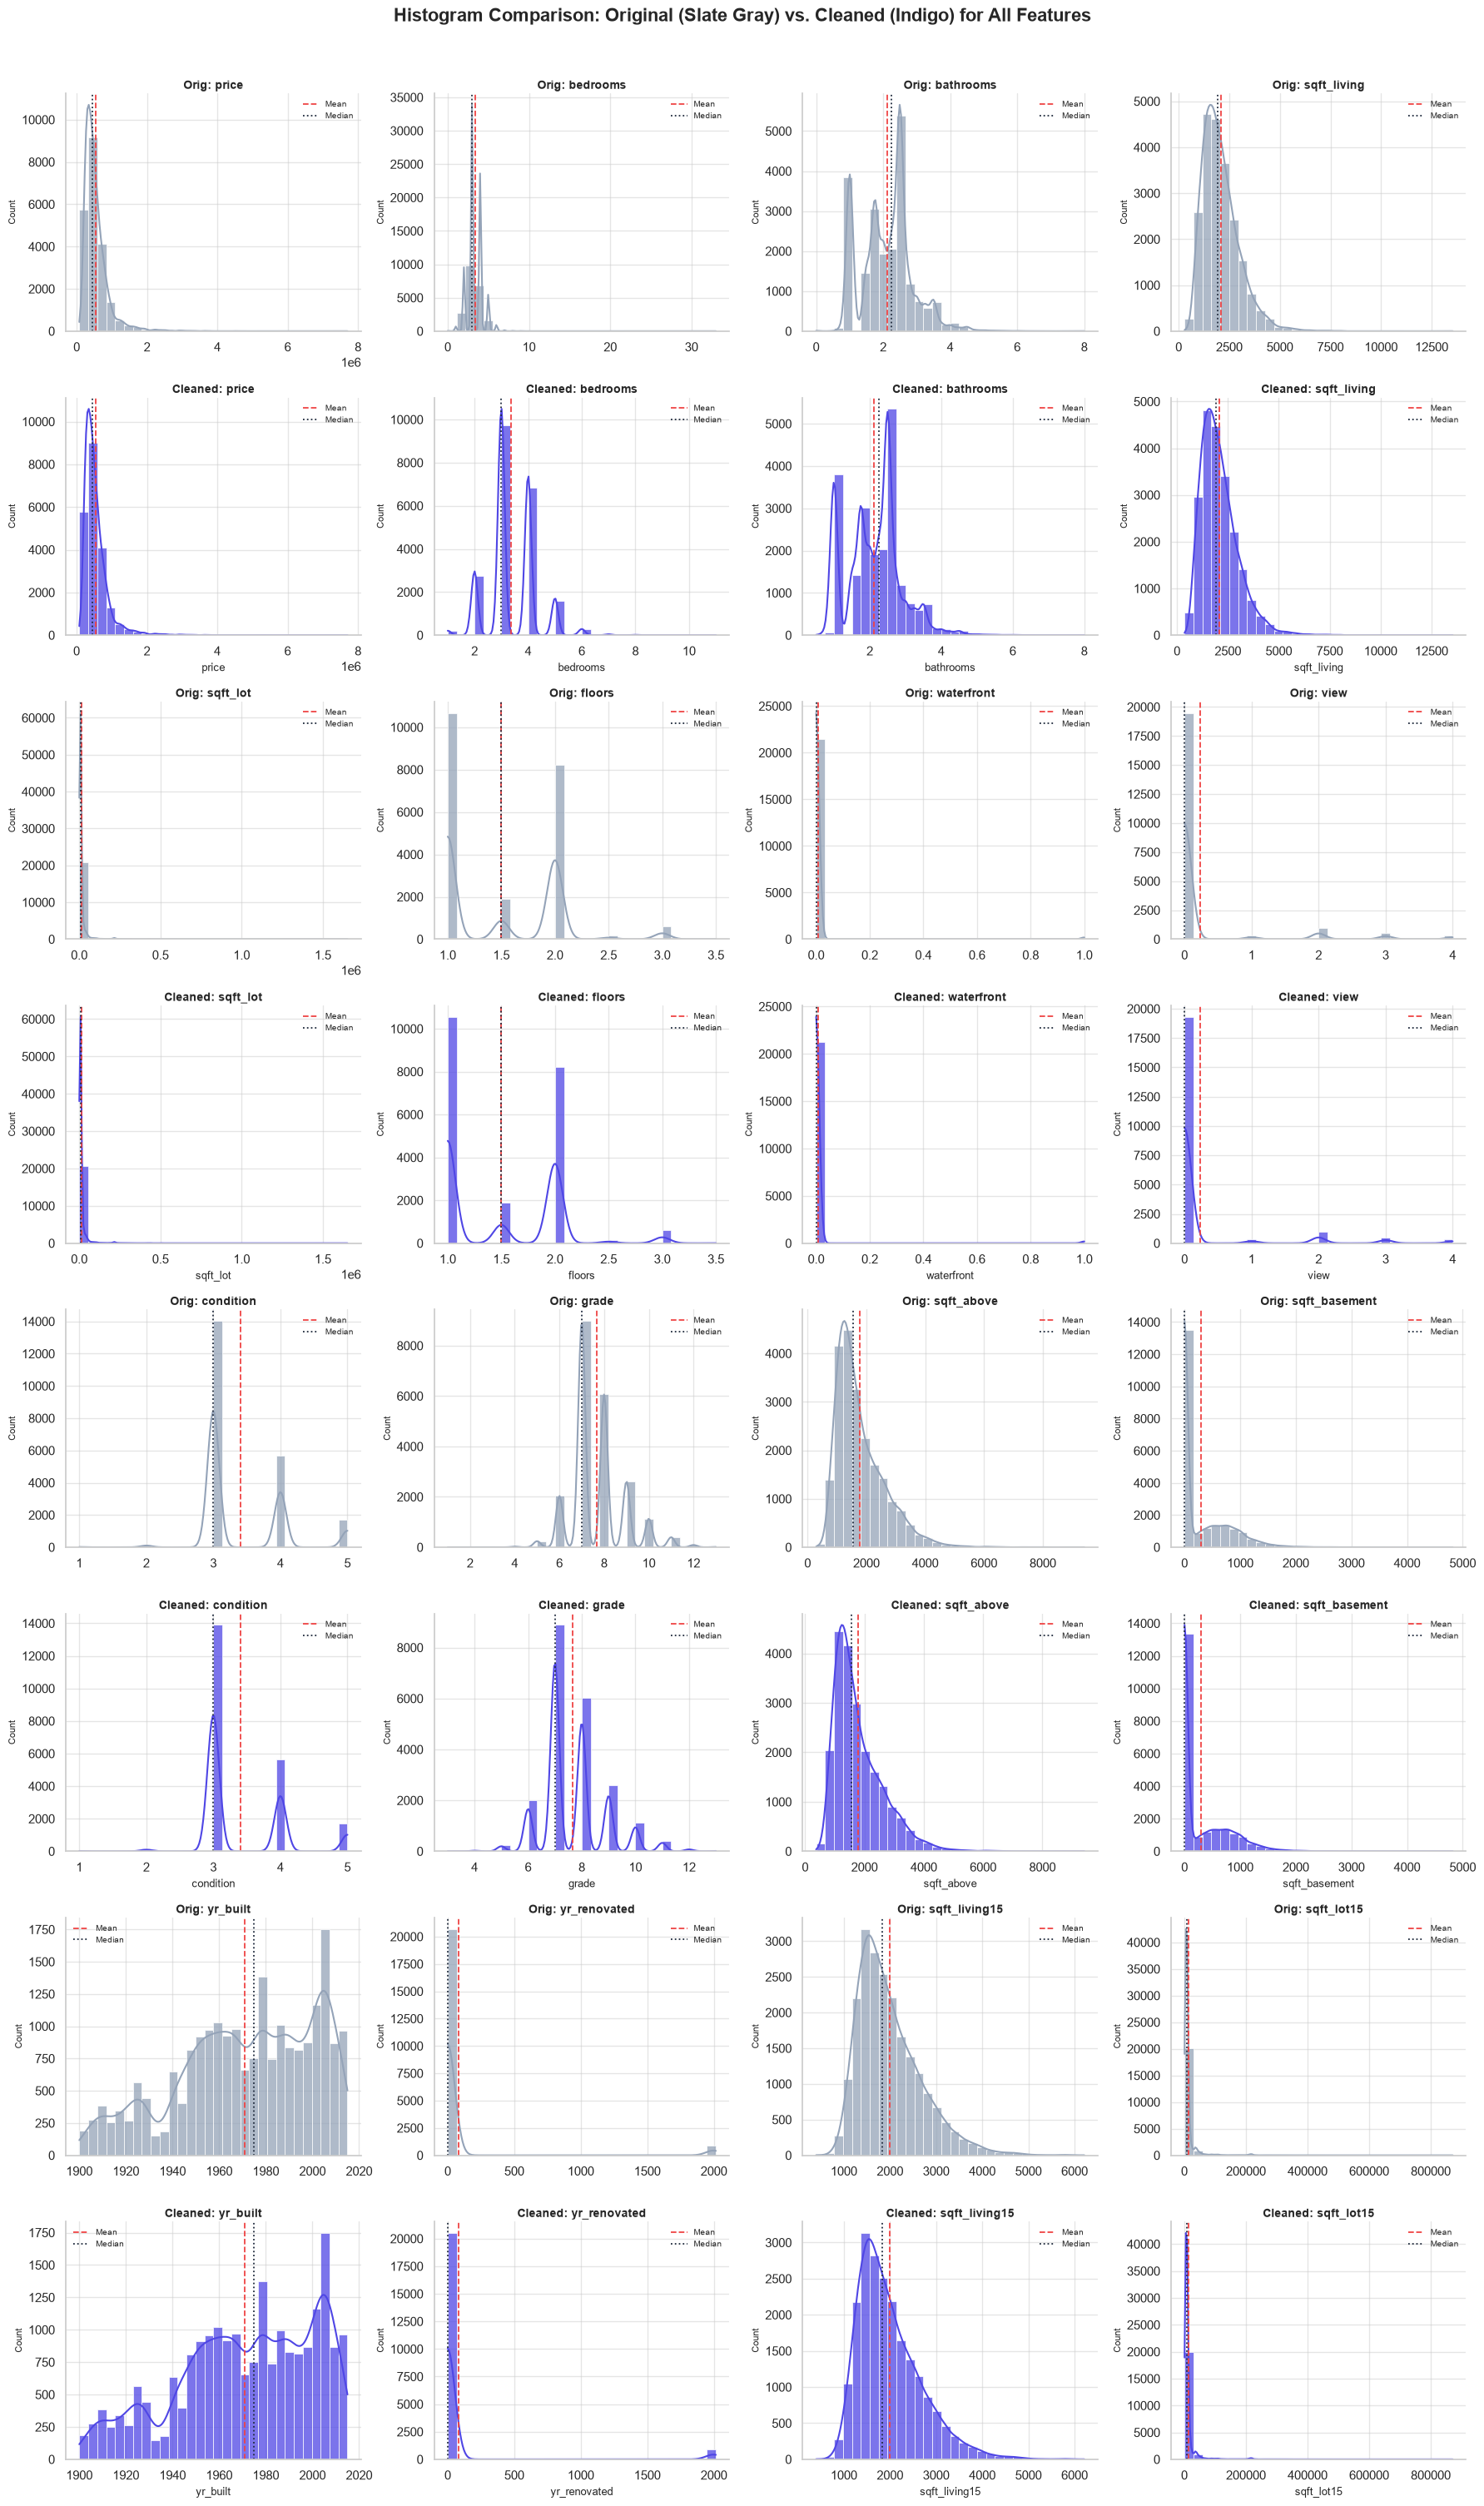

In [18]:
# 1. Identify numeric features to compare
exclude = ["id", "date", "zipcode", "long", "lat"]
plot_features = [c for c in df_original.columns if c not in exclude and pd.api.types.is_numeric_dtype(df_original[c])]
ncols = 4
n_features = len(plot_features)
nrows_feat = int(np.ceil(n_features / ncols))
# We need 2 subplots vertically for each feature row
fig, axes = plt.subplots(nrows_feat * 2, ncols, figsize=(18, 3.8 * nrows_feat * 2))
color_original = "#94A3B8"  # Cool Slate Gray
color_cleaned = "#4F46E5"   # Premium Indigo
# 2. Iterate and plot stacked comparisons
for idx, feat in enumerate(plot_features):
    col = idx % ncols
    row_orig = 2 * (idx // ncols)
    row_clean = row_orig + 1
    
    ax_orig = axes[row_orig, col]
    ax_clean = axes[row_clean, col]
    
    # ------------------ PLOT ORIGINAL ------------------
    sns.histplot(
        data=df_original,
        x=feat,
        bins=30,
        kde=True,
        color=color_original,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.75,
        ax=ax_orig
    )
    # Add Mean & Median lines
    mean_orig = df_original[feat].mean()
    median_orig = df_original[feat].median()
    ax_orig.axvline(mean_orig, color="#EF4444", linestyle="--", linewidth=1.3, label="Mean")
    ax_orig.axvline(median_orig, color="#1E293B", linestyle=":", linewidth=1.3, label="Median")
    
    ax_orig.set_title(f"Orig: {feat}", fontsize=10, fontweight="bold", pad=4)
    ax_orig.set_xlabel("")
    ax_orig.set_ylabel("Count", fontsize=8)
    ax_orig.legend(fontsize=7, frameon=False)
    sns.despine(ax=ax_orig)
    
    # ------------------ PLOT CLEANED ------------------
    sns.histplot(
        data=df,
        x=feat,
        bins=30,
        kde=True,
        color=color_cleaned,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.75,
        ax=ax_clean
    )
    # Add Mean & Median lines
    mean_clean = df[feat].mean()
    median_clean = df[feat].median()
    ax_clean.axvline(mean_clean, color="#EF4444", linestyle="--", linewidth=1.3, label="Mean")
    ax_clean.axvline(median_clean, color="#1E293B", linestyle=":", linewidth=1.3, label="Median")
    
    ax_clean.set_title(f"Cleaned: {feat}", fontsize=10, fontweight="bold", pad=4)
    ax_clean.set_xlabel(feat, fontsize=9)
    ax_clean.set_ylabel("Count", fontsize=8)
    ax_clean.legend(fontsize=7, frameon=False)
    sns.despine(ax=ax_clean)
# 3. Hide any unused subplot slots
total_slots = nrows_feat * 2 * ncols
used_slots_orig = [2 * (i // ncols) * ncols + (i % ncols) for i in range(n_features)]
used_slots_clean = [(2 * (i // ncols) + 1) * ncols + (i % ncols) for i in range(n_features)]
used_slots = set(used_slots_orig + used_slots_clean)
for flat_idx in range(total_slots):
    r = flat_idx // ncols
    c = flat_idx % ncols
    if flat_idx not in used_slots:
        axes[r, c].set_visible(False)
fig.suptitle("Histogram Comparison: Original (Slate Gray) vs. Cleaned (Indigo) for All Features", 
             fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

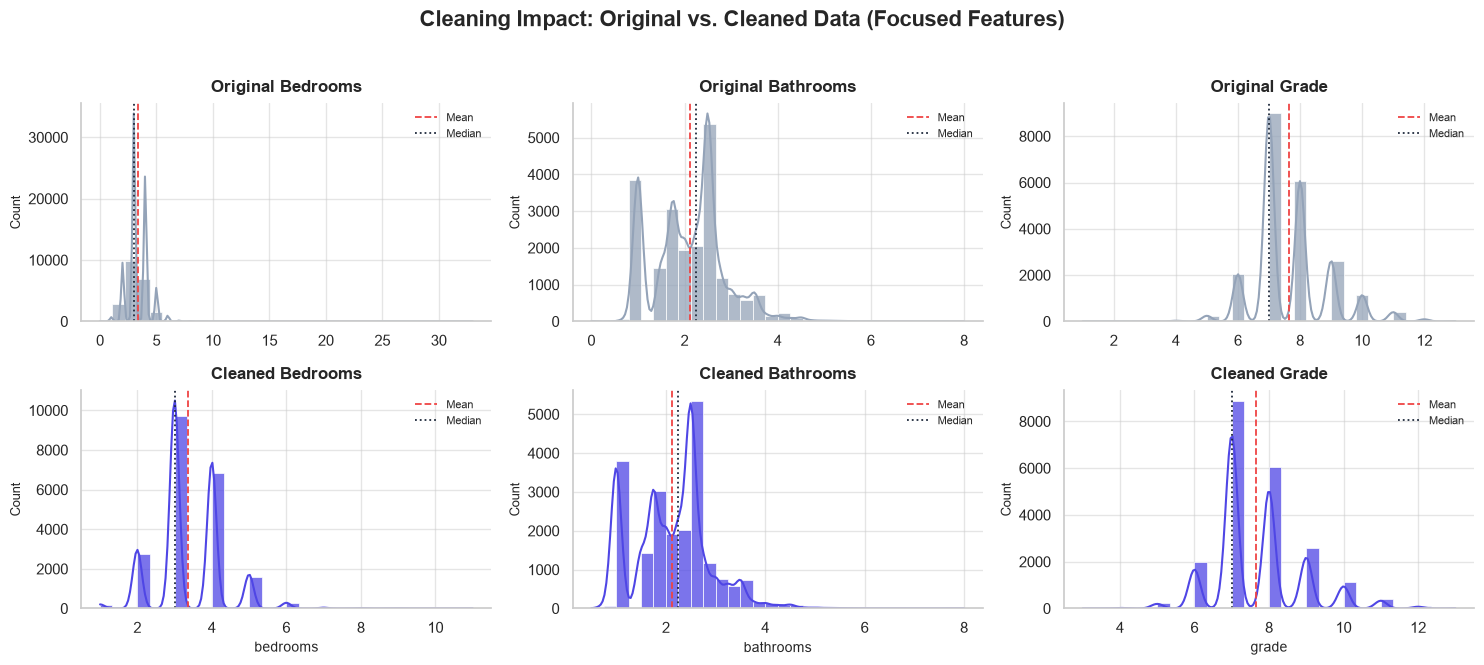

In [19]:
# 1. Focus on the specified key features
focus_features = ["bedrooms", "bathrooms", "grade"]
# 2. Create a 2x3 grid (Row 0: Original, Row 1: Cleaned)
fig, axes = plt.subplots(nrows=2, ncols=len(focus_features), figsize=(15, 6.5))
# Premium color palette: Slate Gray for raw data, Indigo for cleaned data
color_original = "#94A3B8"  
color_cleaned = "#4F46E5"   
# 3. Plot Original Features on the Top Row
for col_idx, feat in enumerate(focus_features):
    ax = axes[0, col_idx]
    sns.histplot(
        data=df_original,
        x=feat,
        bins=30,
        kde=True,
        color=color_original,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.75,
        ax=ax
    )
    # Add Mean & Median lines
    mean_orig = df_original[feat].mean()
    median_orig = df_original[feat].median()
    ax.axvline(mean_orig, color="#EF4444", linestyle="--", linewidth=1.3, label="Mean")
    ax.axvline(median_orig, color="#1E293B", linestyle=":", linewidth=1.3, label="Median")
    
    ax.set_title(f"Original {feat.capitalize()}", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)
    
    # Optional formatting if you add "price" back to focus_features
    if feat == "price":
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M" if x >= 1e6 else f"${x*1e-3:.0f}K"))
# 4. Plot Cleaned Features on the Bottom Row
for col_idx, feat in enumerate(focus_features):
    ax = axes[1, col_idx]
    sns.histplot(
        data=df,
        x=feat,
        bins=30,
        kde=True,
        color=color_cleaned,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.75,
        ax=ax
    )
    # Add Mean & Median lines
    mean_clean = df[feat].mean()
    median_clean = df[feat].median()
    ax.axvline(mean_clean, color="#EF4444", linestyle="--", linewidth=1.3, label="Mean")
    ax.axvline(median_clean, color="#1E293B", linestyle=":", linewidth=1.3, label="Median")
    
    ax.set_title(f"Cleaned {feat.capitalize()}", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)
    
    # Optional formatting if you add "price" back to focus_features
    if feat == "price":
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M" if x >= 1e6 else f"${x*1e-3:.0f}K"))
fig.suptitle("Cleaning Impact: Original vs. Cleaned Data (Focused Features)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Feature Engineering - aus bestehenden Features neue Features extrahieren

In [20]:
# Seattle Zentrum Koordinaten (Spaceneedle)
seattle_lat = 47.6062
seattle_long = -122.3321
# Haus Distanz zum Zentrum
df['distance_to_center'] = np.sqrt((df['lat'] - seattle_lat)**2 + (df['long'] - seattle_long)**2)

# Preis pro sqft_living
df['price_per_sqft_living'] = df['price'] / df['sqft_living']
# Preis pro sqft_lot
df['price_per_sqft_lot'] = df['price'] / df['sqft_lot']

# Schlafzimmer pro sqft_living
df['bedrooms_per_sqft_living'] = df['bedrooms'] / df['sqft_living']
# Badezimmer pro sqft_living
df['bathrooms_per_sqft_living'] = df['bathrooms'] / df['sqft_living']

# Keller erkennen
df['has_basement'] = df['sqft_basement'].apply(lambda x: 1 if x > 0 else 0)

# Alter des Hauses zum Zeitpunkt 2015
df['house_age'] = 2015 - df['yr_built']

# Renovierungen erkennen
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
# Zeit seit Renovierung
df['years_since_renovation'] = df.apply(lambda row: 2015 - row['yr_renovated'] if row['yr_renovated'] > 0 else row['house_age'], axis=1)

# Durchschnittliche Raum größe
df['avg_room_size'] = df['sqft_living'] / (df['bedrooms'] + df['bathrooms'] + 1)

# Garten Berechnen
df['yard_space_approx'] = df['sqft_lot'] - (df['sqft_living'] / df['floors'])
# Vermeidung negativer Werte beim Garten
df['yard_space_approx'] = df['yard_space_approx'].apply(lambda x: x if x > 0 else 0)

# Luxus score
# df['luxury_score'] = (df['grade'] / 13) + (df['condition'] / 5) + (df['waterfront'] / 3) + (df['view'] / 4)
df['luxury_score'] = (df['grade'] / 13) + (df['view'] / 4)

# Koordinaten zu einer Grid-Zelle verknüpfen
df['grid_cell_id'] = df['lat'].round(2).astype(str) + "_" + df['long'].round(2).astype(str)
# Text-String label-encoden
df['grid_cell_id'] = df['grid_cell_id'].astype('category').cat.codes


display(df.head())


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,bedrooms_per_sqft_living,bathrooms_per_sqft_living,has_basement,house_age,is_renovated,years_since_renovation,avg_room_size,yard_space_approx,luxury_score,grid_cell_id
0,2202500290,20140502T000000,435000.0,4,1.0,1450,8800,1.0,0,0,...,0.002759,0.000690,0,61,0,61,241.666667,7350.0,0.538462,1134
1,7853361370,20140502T000000,555000.0,4,2.5,3310,6500,2.0,0,0,...,0.001208,0.000755,0,3,0,3,441.333333,4845.0,0.615385,903
2,7197300105,20140502T000000,550000.0,4,2.5,1940,10500,1.0,0,0,...,0.002062,0.001289,1,39,0,39,258.666667,8560.0,0.538462,1545
3,3438501320,20140502T000000,295000.0,2,2.5,1630,1368,2.0,0,0,...,0.001227,0.001534,1,6,0,6,296.363636,553.0,0.538462,1066
4,472000620,20140502T000000,790000.0,3,2.5,2600,4750,1.0,0,0,...,0.001154,0.000962,1,64,0,64,400.000000,2150.0,0.692308,1567


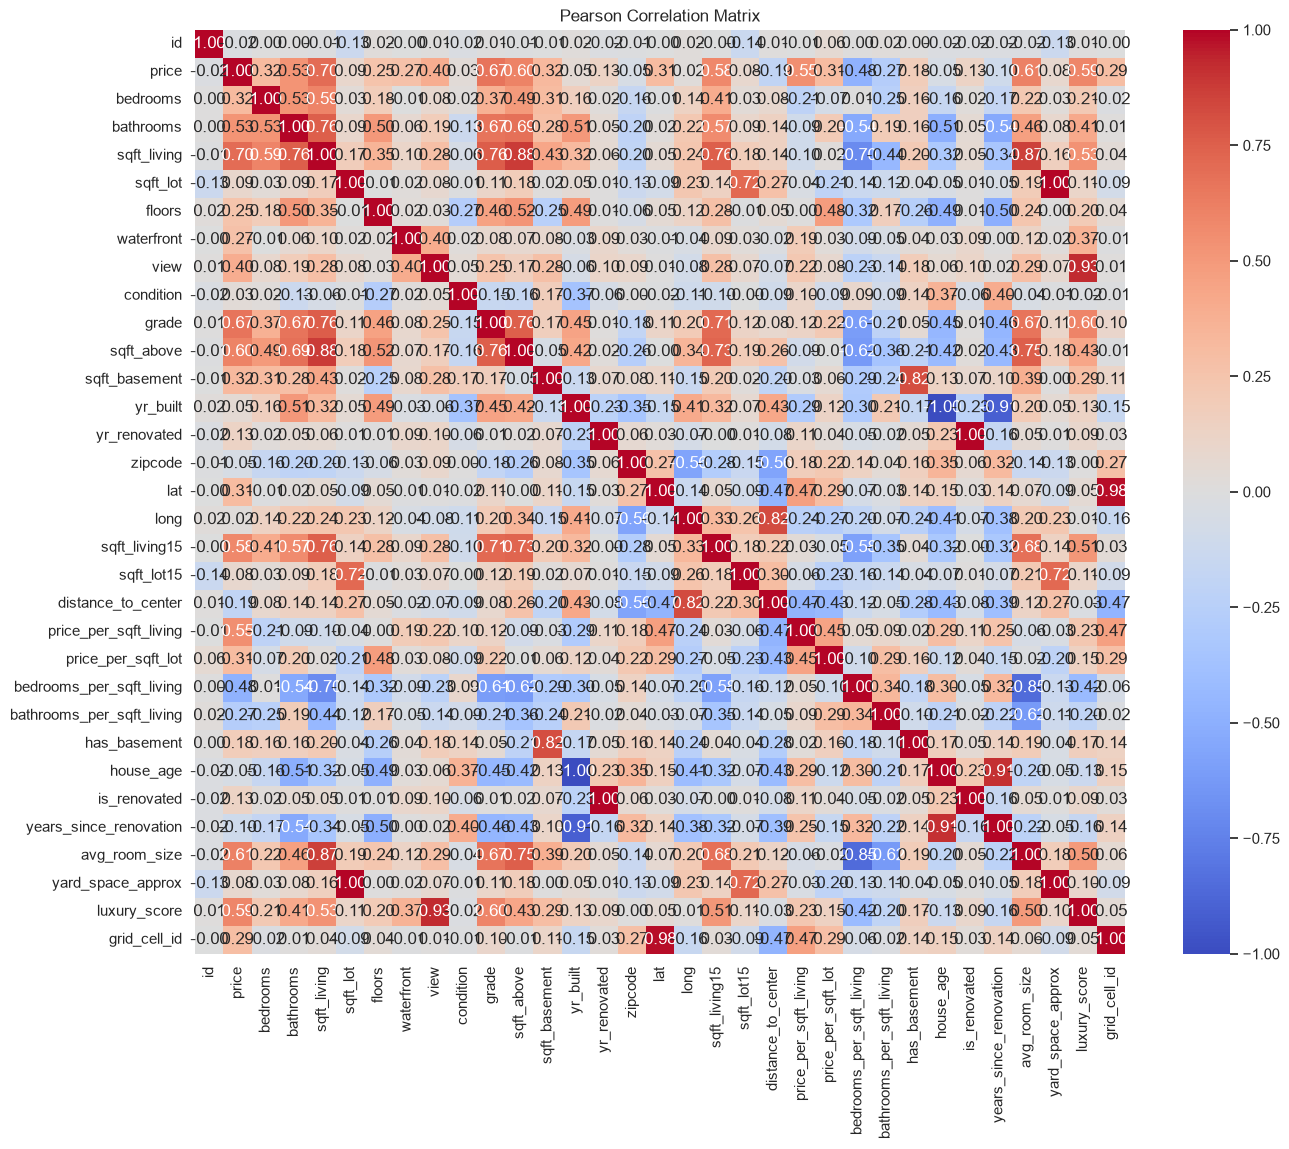

Dataset geladen: 21420 Zeilen, 34 Spalten


In [21]:
# Calculate the Pearson correlation matrix
corr_matrix = df.corr(method='pearson', numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(15, 12)) # Increased figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()
print(f"Dataset geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

In [22]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21420.0,NaN,NaN,NaN,4580939869.15761,2876761172.448412,1000102.0,2123537386.75,3904921185.0,7308900186.25,9900000190.0
date,21420,372,20140623T000000,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,21420.0,NaN,NaN,NaN,541766.855789,367321.159549,78000.0,324950.0,450550.0,645000.0,7700000.0
bedrooms,21420.0,NaN,NaN,NaN,3.372549,0.902995,1.0,3.0,3.0,4.0,11.0
bathrooms,21420.0,NaN,NaN,NaN,2.118429,0.76872,0.5,1.75,2.25,2.5,8.0
sqft_living,21420.0,NaN,NaN,NaN,2083.132633,918.808412,370.0,1430.0,1920.0,2550.0,13540.0
sqft_lot,21420.0,NaN,NaN,NaN,15128.038002,41530.796838,520.0,5040.0,7614.0,10690.5,1651359.0
floors,21420.0,NaN,NaN,NaN,1.495985,0.540081,1.0,1.0,1.5,2.0,3.5
waterfront,21420.0,NaN,NaN,NaN,0.00761,0.086903,0.0,0.0,0.0,0.0,1.0
view,21420.0,NaN,NaN,NaN,0.235107,0.767165,0.0,0.0,0.0,0.0,4.0


In [23]:
df[np.isclose(df['avg_room_size'], 1440.0)]


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,bedrooms_per_sqft_living,bathrooms_per_sqft_living,has_basement,house_age,is_renovated,years_since_renovation,avg_room_size,yard_space_approx,luxury_score,grid_cell_id
13590,7524900003,20141210T000000,3278000.0,2,1.75,6840,10000,2.5,1,4,...,0.000292,0.000256,1,14,0,14,1440.0,7264.0,1.846154,1621


In [24]:
# 1. Read the original data again into a temporary variable
df_orig = pd.read_csv(os.path.join(path, csv_file))

# 2. Get the row indices matching your condition
matching_indices = df[np.isclose(df['price_per_sqft_lot'], 0.163119)].index

# 3. View the bedrooms and bathrooms from the original data
df_orig.loc[matching_indices, ['bedrooms', 'bathrooms', 'price','sqft_living', 'sqft_lot']]


,bedrooms,bathrooms,price,sqft_living,sqft_lot
20944,5,3.5,925000.0,3420,4216


In [25]:
new_features = ['distance_to_center', 'price_per_sqft_living', 'price_per_sqft_lot', 'bedrooms_per_sqft_living',
'bathrooms_per_sqft_living', 'has_basement', 'house_age', 'is_renovated', 'years_since_renovation', 'avg_room_size',
'yard_space_approx', 'luxury_score', 'grid_cell_id']

df_new_features = df[new_features]

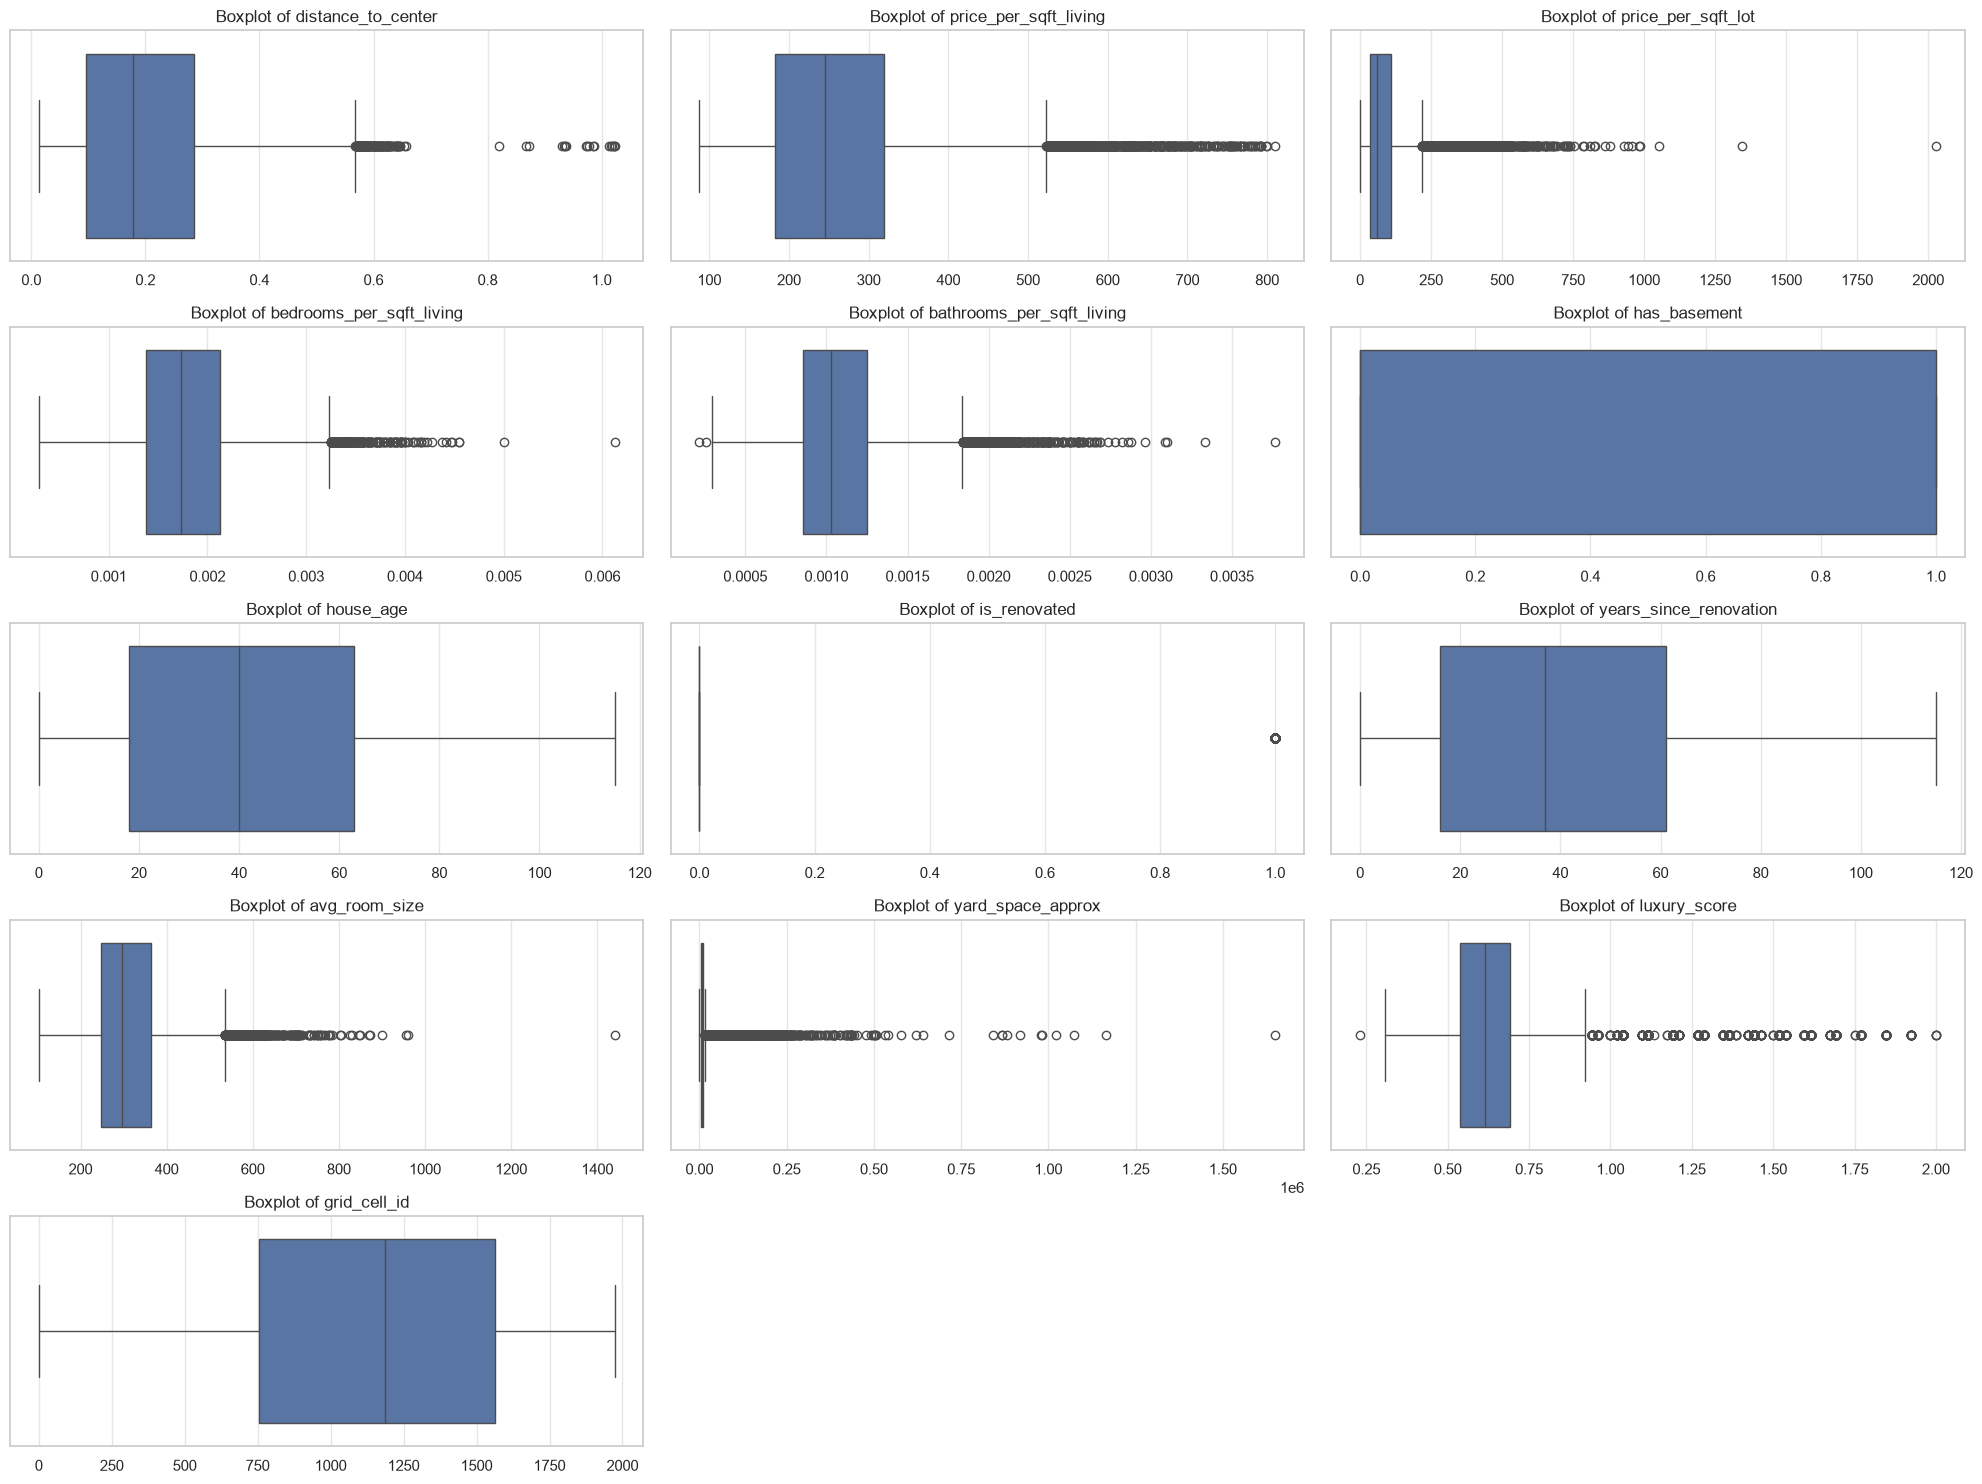

In [26]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure for the boxplots
plt.figure(figsize=(20, 15))

# Create a boxplot for each of the new features
for i, feature in enumerate(new_features, 1):
    plt.subplot(5, 3, i)
    # Use the 'x' parameter for horizontal boxplots
    sns.boxplot(data=df, x=feature)
    plt.title(f'Boxplot of {feature}')
    plt.xlabel('')

plt.tight_layout()
plt.show()


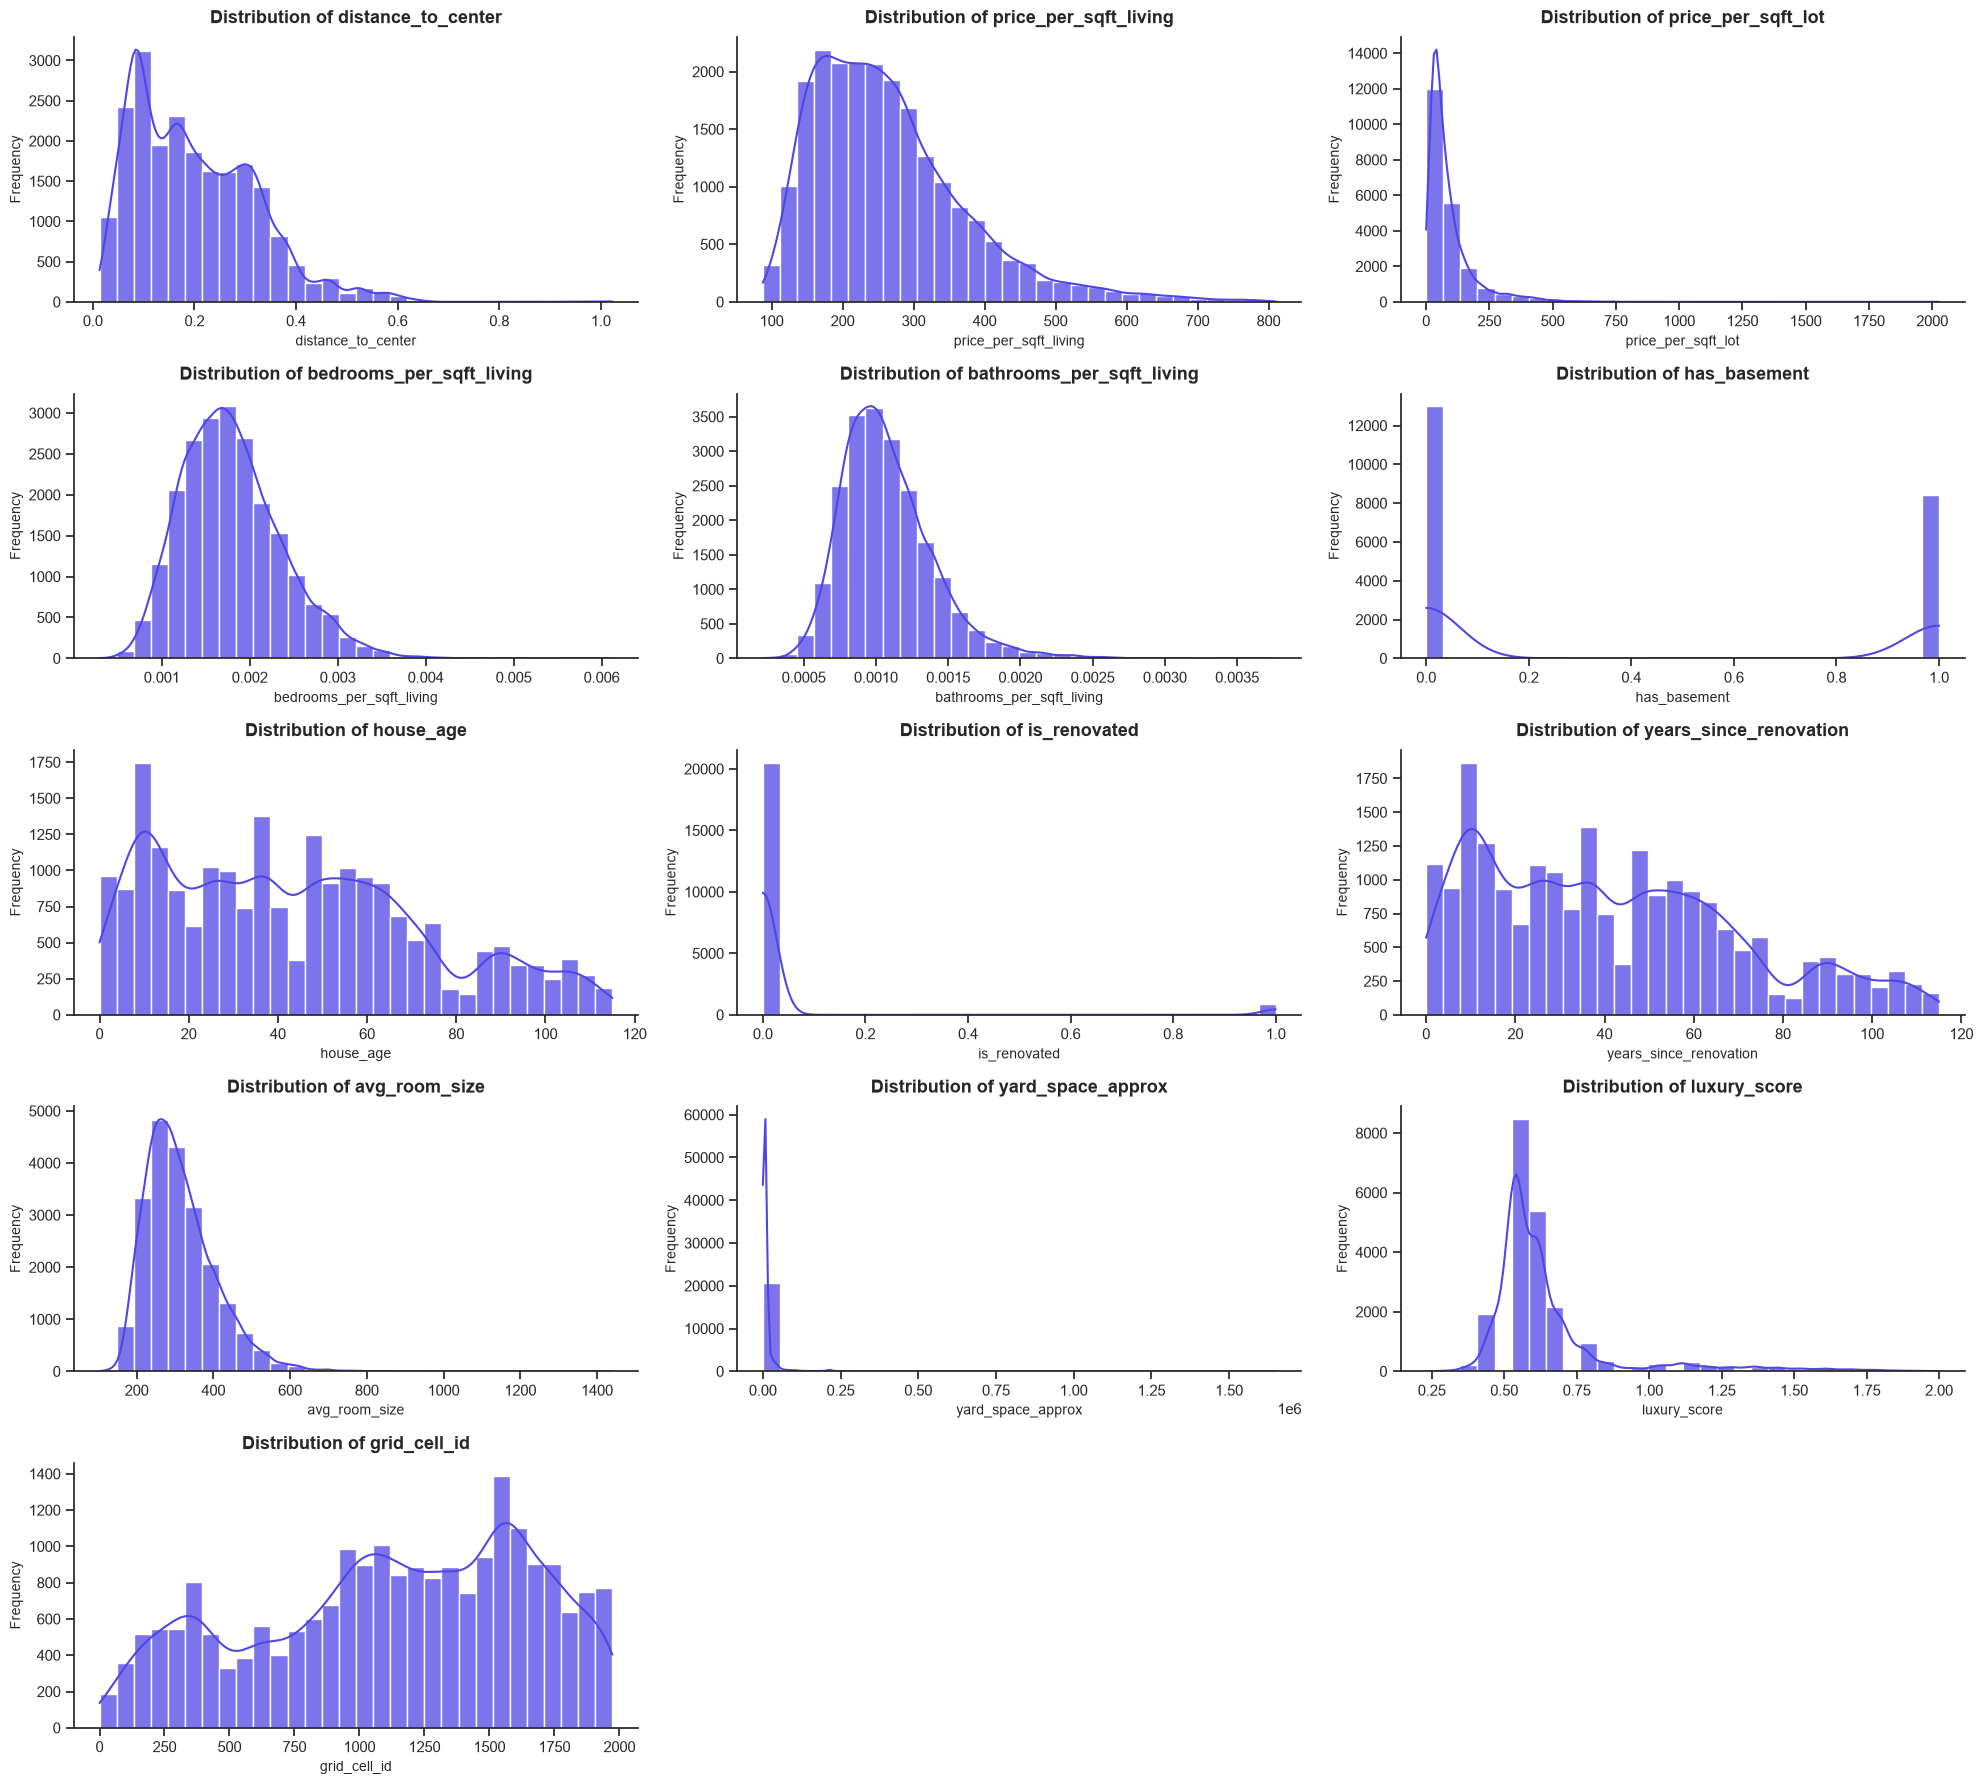

In [27]:
# 2. Set a premium, clean design style
sns.set_theme(style="white")
sns.set_style("ticks")
plt.rcParams['font.sans-serif'] = 'Arial'

# Create a figure for the grid of subplots
fig = plt.figure(figsize=(20, 18))

# Choose a modern color palette (e.g., Indigo #4F46E5)
plot_color = "#4F46E5"

# 3. Create a histogram with a KDE (Kernel Density Estimate) for each feature
for i, feature in enumerate(new_features, 1):
    ax = plt.subplot(5, 3, i)

    # Plot histogram with density line
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        color=plot_color,
        bins=30,
        edgecolor="white",
        alpha=0.75
    )

    # Polish the titles and labels
    plt.title(f'Distribution of {feature}', fontsize=13, fontweight='bold', pad=10)
    plt.xlabel(feature, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)

    # Remove top and right borders for a cleaner look
    sns.despine()

# 4. Hide unused subplot slots (slots 14 and 15 in the 5x3 grid)
total_slots = 5 * 3
for j in range(len(new_features) + 1, total_slots + 1):
    fig.add_subplot(5, 3, j).axis('off')

plt.tight_layout()
plt.show()


In [28]:
interesting_features = [ #price "price" Preis ist eigentlich Ergebnis, kein Käufer-Merkmal
                         #"sqft_living",
                        "bedrooms",
                        #"bathrooms", #brauchen wir eigenltich nicht, also für keine Hypothese
                        "luxury_score", #waterfront entfernt, jetzt = grade + view
                        "condition",
                        # "distance_to_center",
                        "sqft_lot", #hinzugefügt, log_yard_space_approx war falsch, also falsche annahme
                        #"years_since_renovation", #brauchen wir das für unsere Hypothesen, ja/nein?
                        "waterfront",
                        "lat",
                        "long",
                        ]

df_reduced = df[interesting_features]

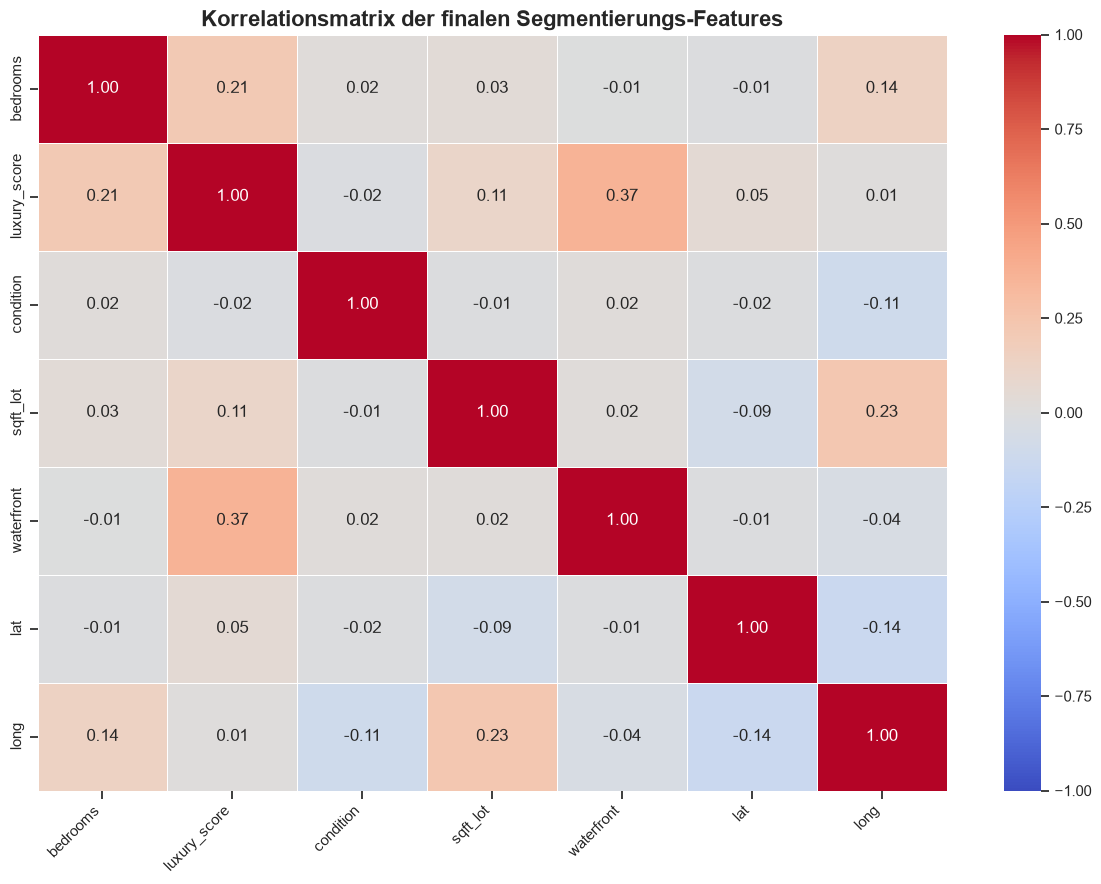

In [29]:
# Korrelationsmatrix berechnen (Pearson)
corr_matrix = df_reduced.corr()

# Heatmap visualisieren
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Schreibt die Zahlen in die Kästchen
    cmap='coolwarm',     # Rot = Starke Korrelation, Blau = Negative Korrelation
    vmin=-1, vmax=1, 
    fmt=".2f",
    linewidths=0.5
)

plt.title("Korrelationsmatrix der finalen Segmentierungs-Features", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

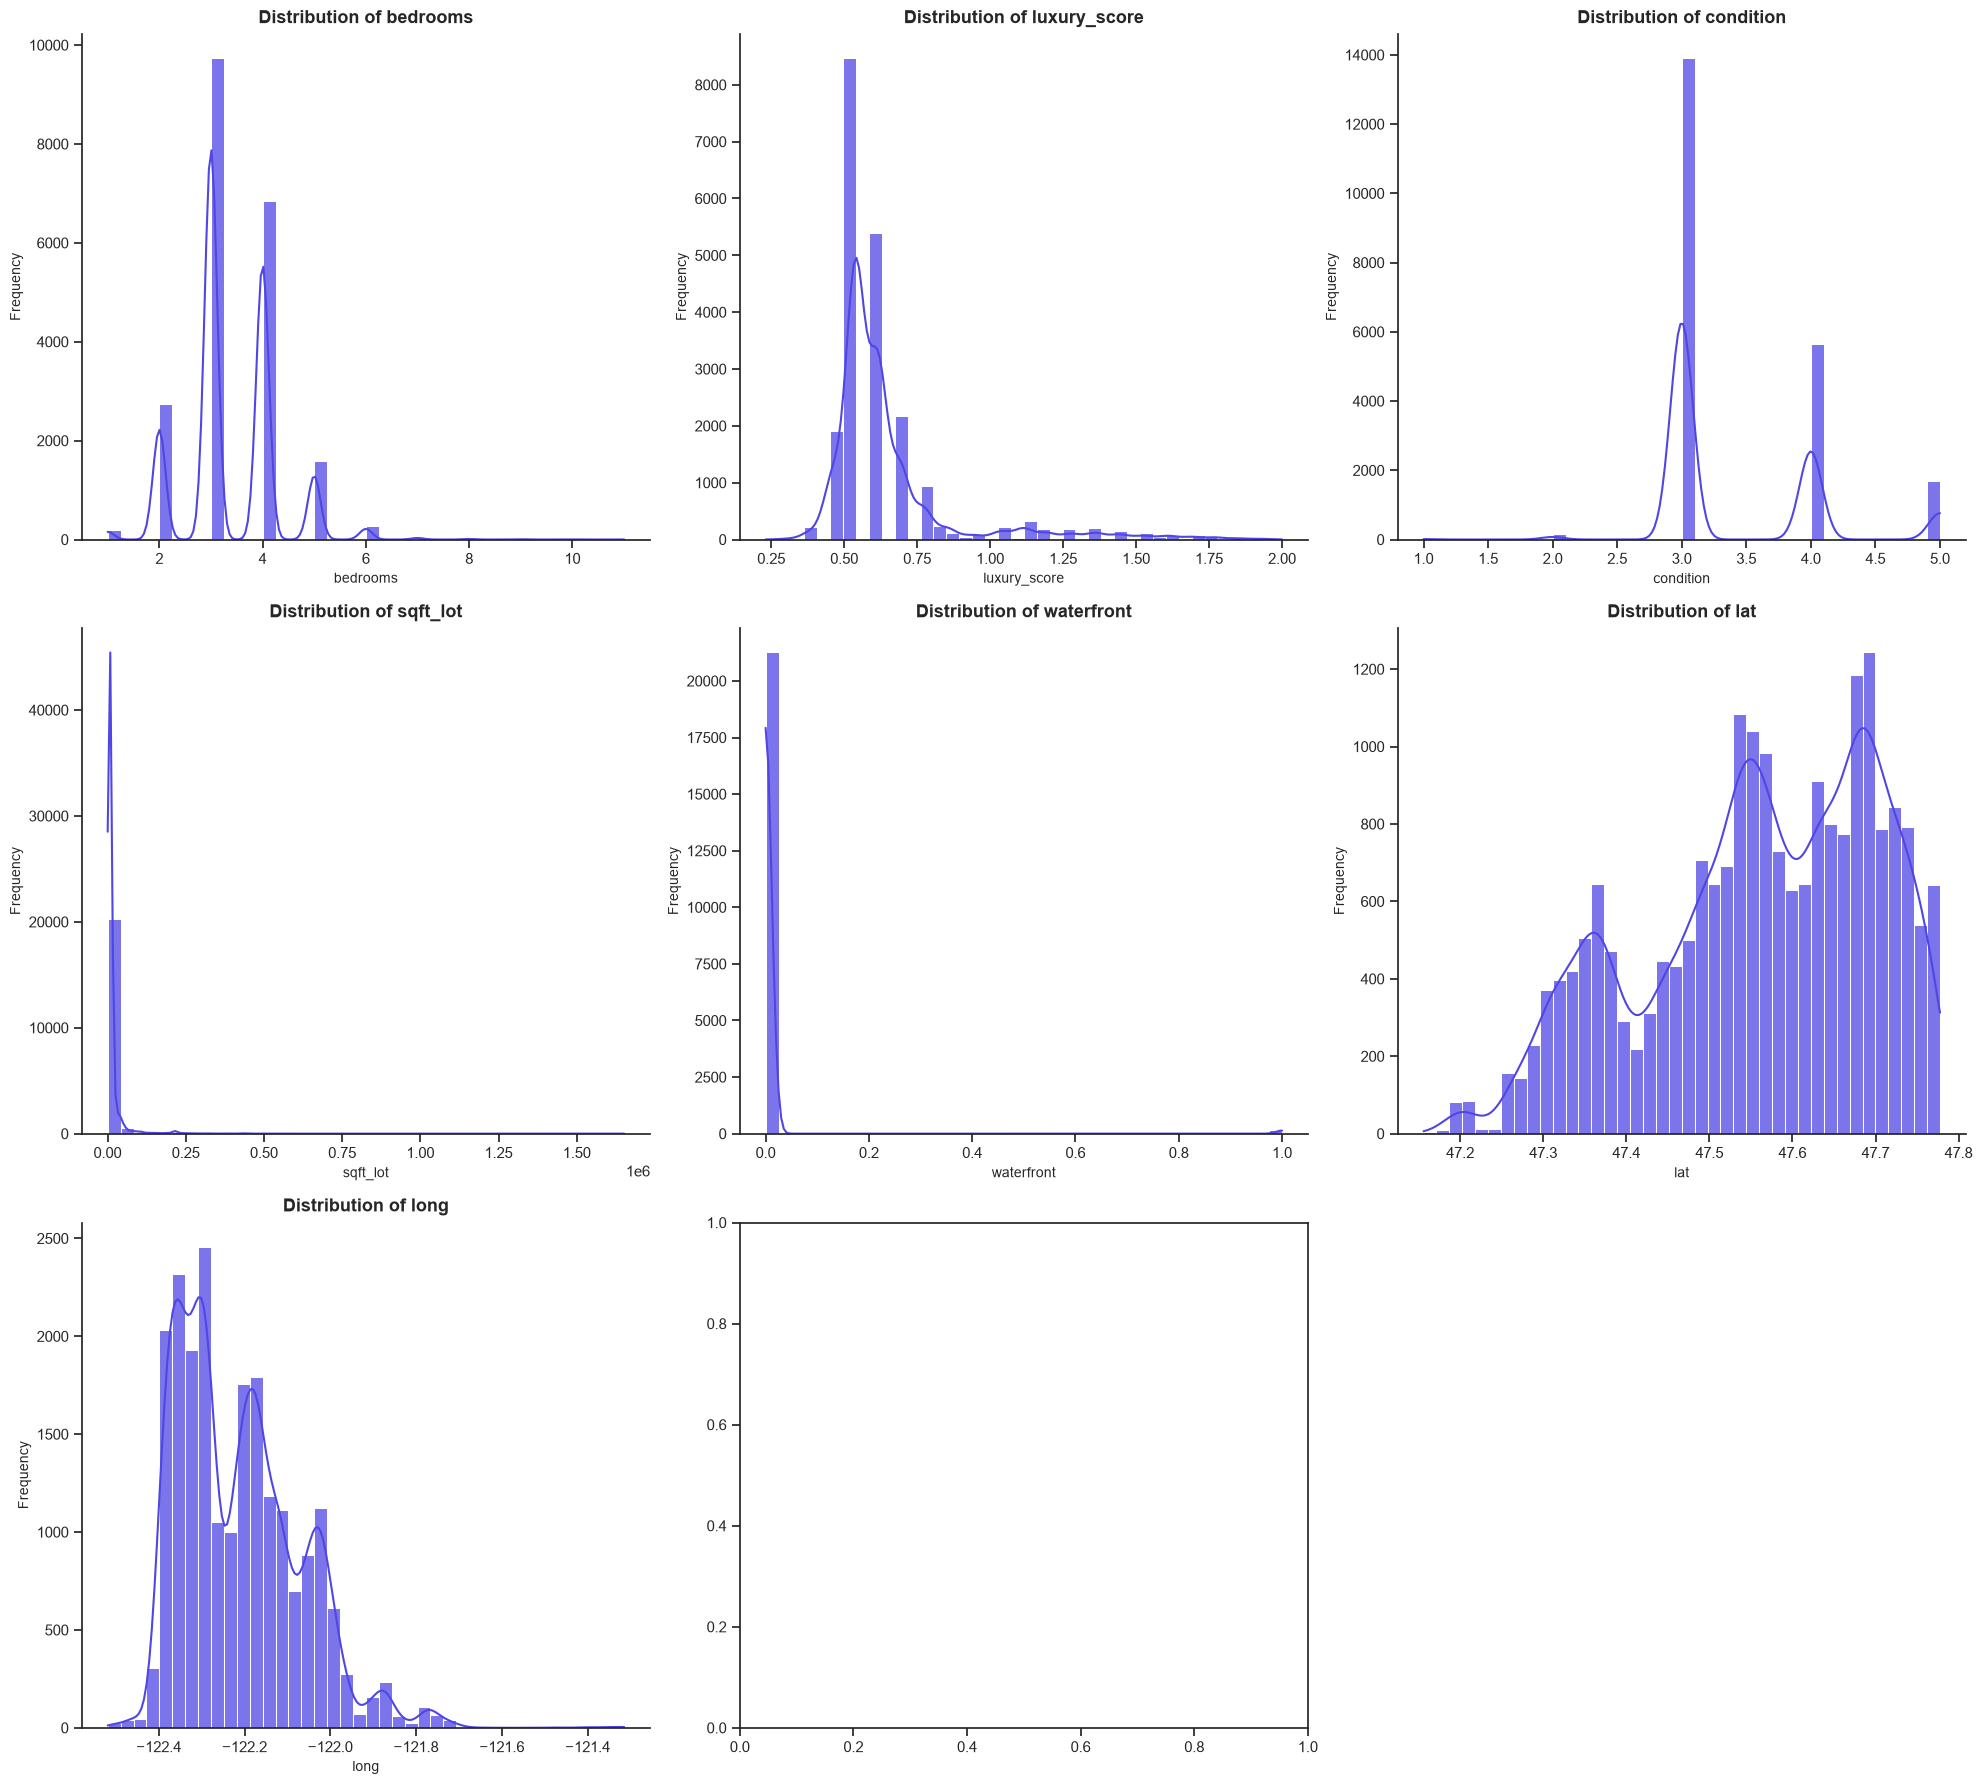

In [30]:
# Set a clean, modern style
sns.set_theme(style="white")
sns.set_style("ticks")
# Create a 3x3 grid of subplots for the 9 features
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()
# Premium indigo color for the bars
plot_color = "#4F46E5"
# Loop through and plot each column in df_reduced
for i, col in enumerate(df_reduced.columns):
    sns.histplot(
        data=df_reduced, 
        x=col, 
        kde=True, 
        ax=axes[i], 
        color=plot_color, 
        bins=40,
        edgecolor="white", 
        alpha=0.75
    )
    
    # Format the titles and axis labels
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold', pad=8)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    
    # Clean up the plot borders
    sns.despine(ax=axes[i])

# Hide the 9th unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()


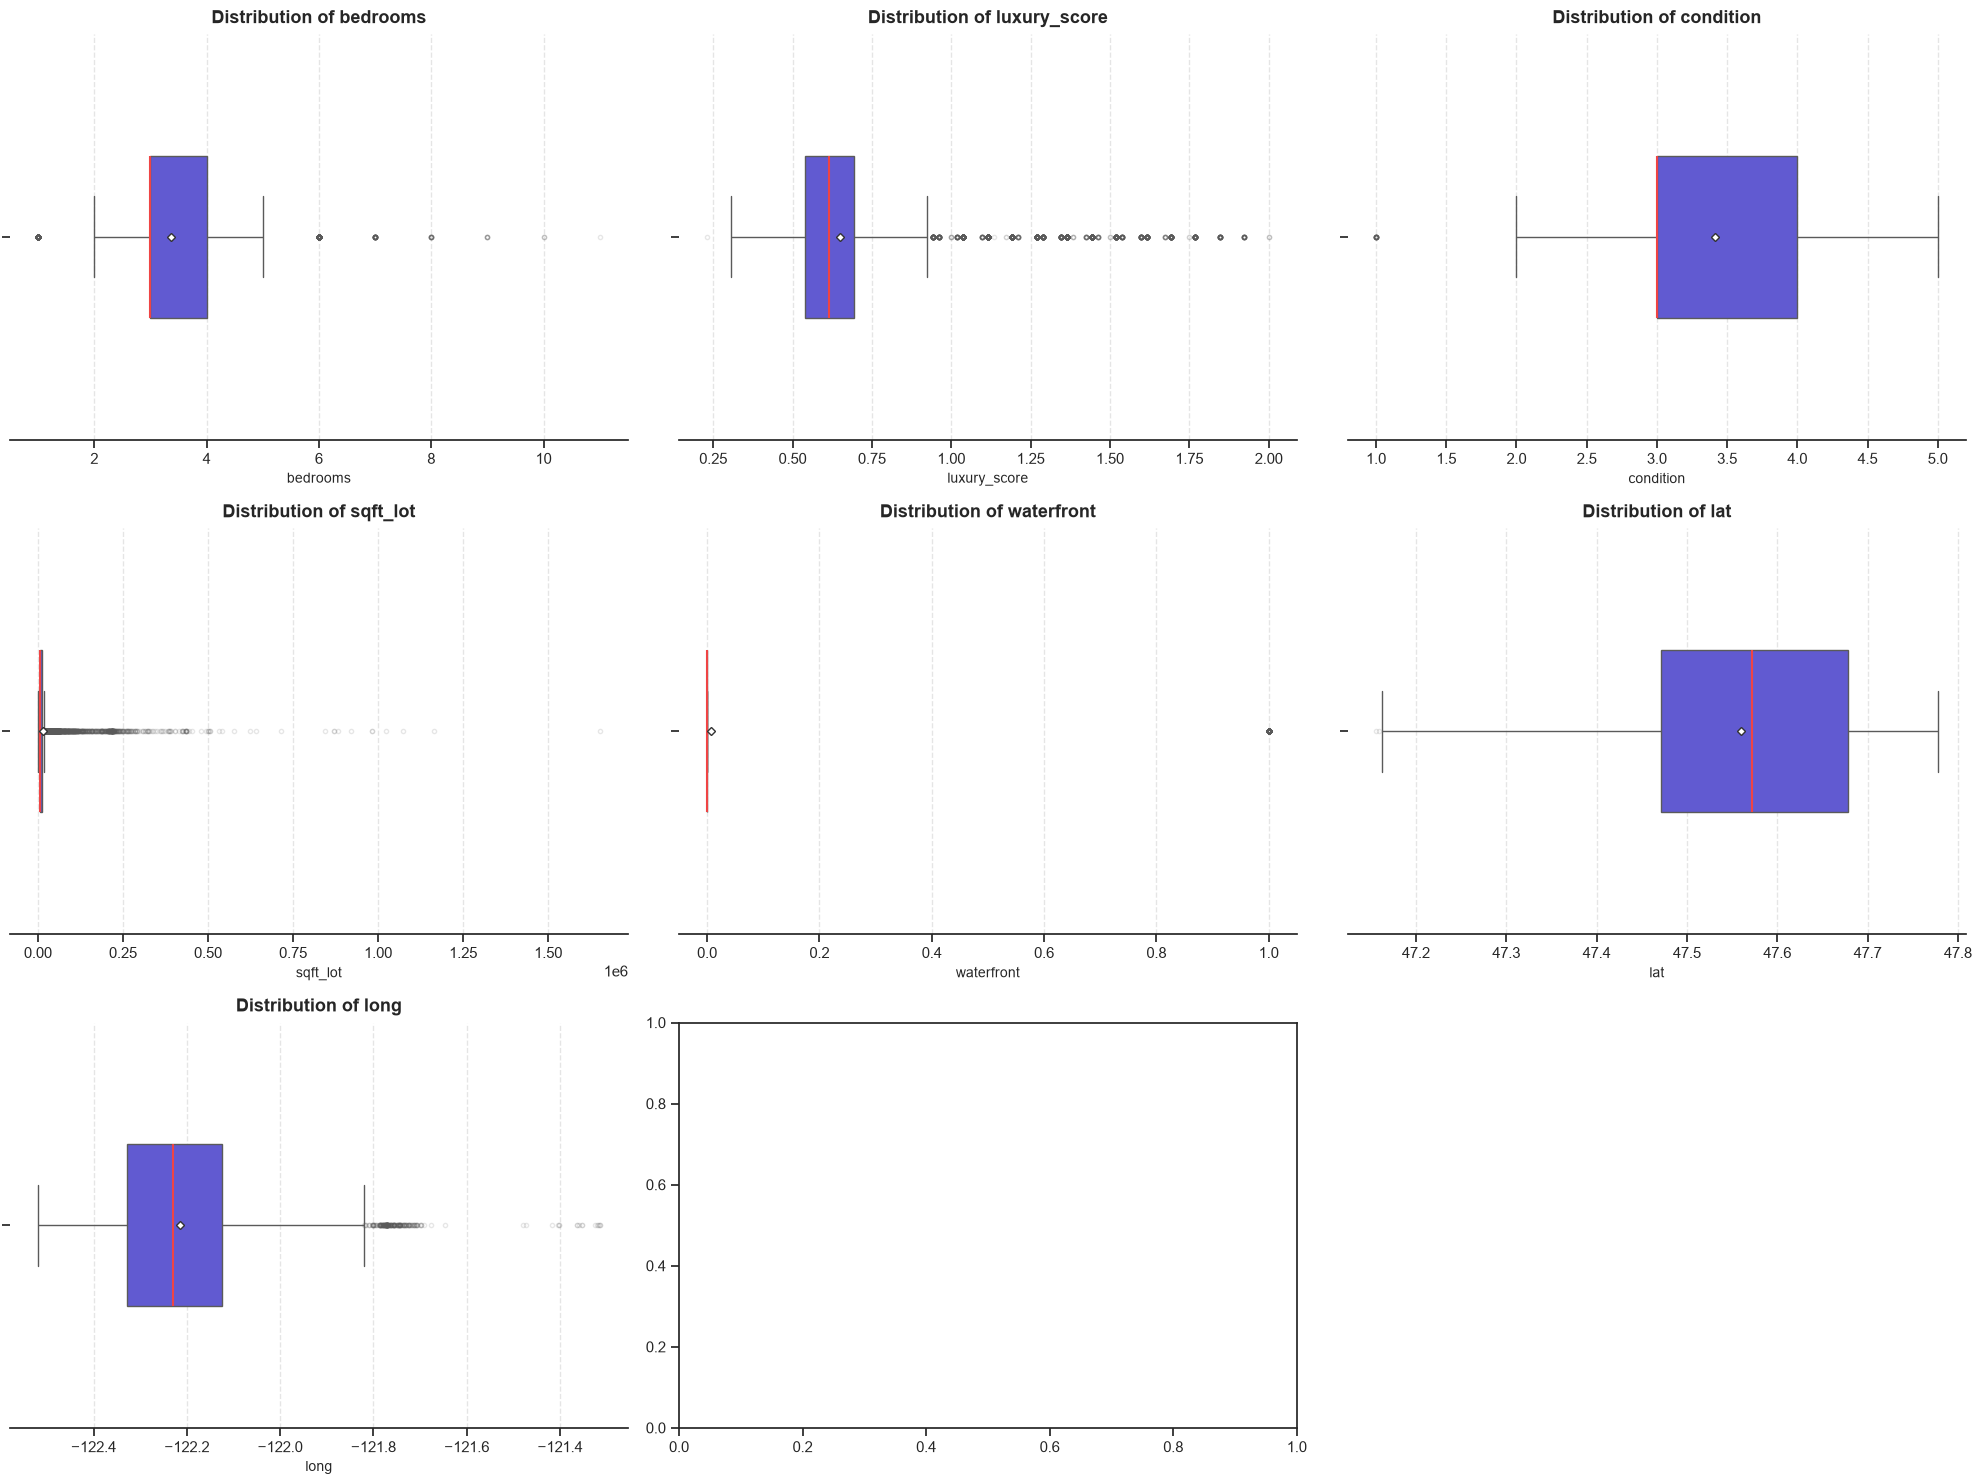

In [31]:
# Set a clean, modern style
sns.set_theme(style="white")
sns.set_style("ticks")
# Create a 3x3 grid of subplots for the features
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()
# Premium indigo color for the boxes
plot_color = "#4F46E5"
# Loop through and plot each column in df_reduced
for i, col in enumerate(df_reduced.columns):
    sns.boxplot(
        data=df_reduced, 
        x=col, 
        ax=axes[i], 
        color=plot_color,
        width=0.4,
        showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333333", markersize=4),
        medianprops=dict(color="#EF4444", linewidth=1.5),  # Distinct rose-red median line
        flierprops=dict(marker="o", markersize=3, alpha=0.15)
    )
    
    # Format the titles and axis labels
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold', pad=8)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('')  # Clear the y-label for horizontal boxplots
    axes[i].grid(axis="x", linestyle="--", alpha=0.5)  # Add subtle vertical gridlines
    
    # Clean up the plot borders (removing the ticks on the left axis since there's only one group)
    sns.despine(ax=axes[i], left=True)
# Hide the 9th unused subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()

Attribute Transformation

In [32]:
# 1. Apply log transformations ONLY to the skewed features present in your new df_reduced
df_reduced = df_reduced.copy()                     # vermeidet SettingWithCopyWarning
df_reduced['log_lot'] = np.log(df_reduced['sqft_lot'])
# 2. Select your updated final features (dropping original skewed ones and keeping the log ones)
final_features = [
                        "bedrooms",
                        "luxury_score", #waterfront entfernt, jetzt = grade + view
                        "log_lot", #hinzugefügt, log_yard_space_approx war falsch, also falsche annahme
                        "condition",
                        "lat",
                        "long",
                        "waterfront"
                ]
df_final = df_reduced[final_features]

# 3. Z-Transform (Standardize) the final features
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_final), 
    columns=df_final.columns, 
    index=df_final.index
)

# 4. Profil-/Validierungsspalten ROH anhängen (nicht standardisiert, nicht fürs Clustering)
profile_cols = ['price', 'sqft_living','distance_to_center']
for c in profile_cols:
    df_scaled['prof_' + c] = df.loc[df_scaled.index, c]   # per Index -> Zuordnung garantiert

df_scaled.head()

,bedrooms,luxury_score,log_lot,condition,lat,long,waterfront,prof_price,prof_sqft_living,prof_distance_to_center
0,0.694872,-0.474253,0.102708,0.906458,0.103926,0.559594,-0.087567,435000.0,1450,0.199617
1,0.694872,-0.141885,-0.232475,-0.631956,-0.326132,2.441867,-0.087567,555000.0,3310,0.471014
2,0.694872,-0.474253,0.298124,0.906458,0.886112,0.708755,-0.087567,550000.0,1940,0.231227
3,-1.520031,-0.474253,-1.956745,-0.631956,-0.081518,-1.059871,-0.087567,295000.0,1630,0.065101
4,-0.412580,0.190483,-0.579506,0.906458,0.888276,-1.322679,-0.087567,790000.0,2600,0.102737


In [33]:
# Überprüfung der Standardabweichung (sollte überall ~1.0 sein)
print("Standardabweichungen:")
print(df_scaled.std())

print("\nMittelwerte:")
# Überprüfung des Mittelwerts (sollte überall ~0.0 sein)
print(df_scaled.mean().round(6))


Standardabweichungen:
bedrooms                        1.000023
luxury_score                    1.000023
log_lot                         1.000023
condition                       1.000023
lat                             1.000023
long                            1.000023
waterfront                      1.000023
prof_price                 367321.159549
prof_sqft_living              918.808412
prof_distance_to_center         0.121748
dtype: float64

Mittelwerte:
bedrooms                        0.000000
luxury_score                    0.000000
log_lot                         0.000000
condition                       0.000000
lat                            -0.000000
long                           -0.000000
waterfront                     -0.000000
prof_price                 541766.855789
prof_sqft_living             2083.132633
prof_distance_to_center         0.200799
dtype: float64


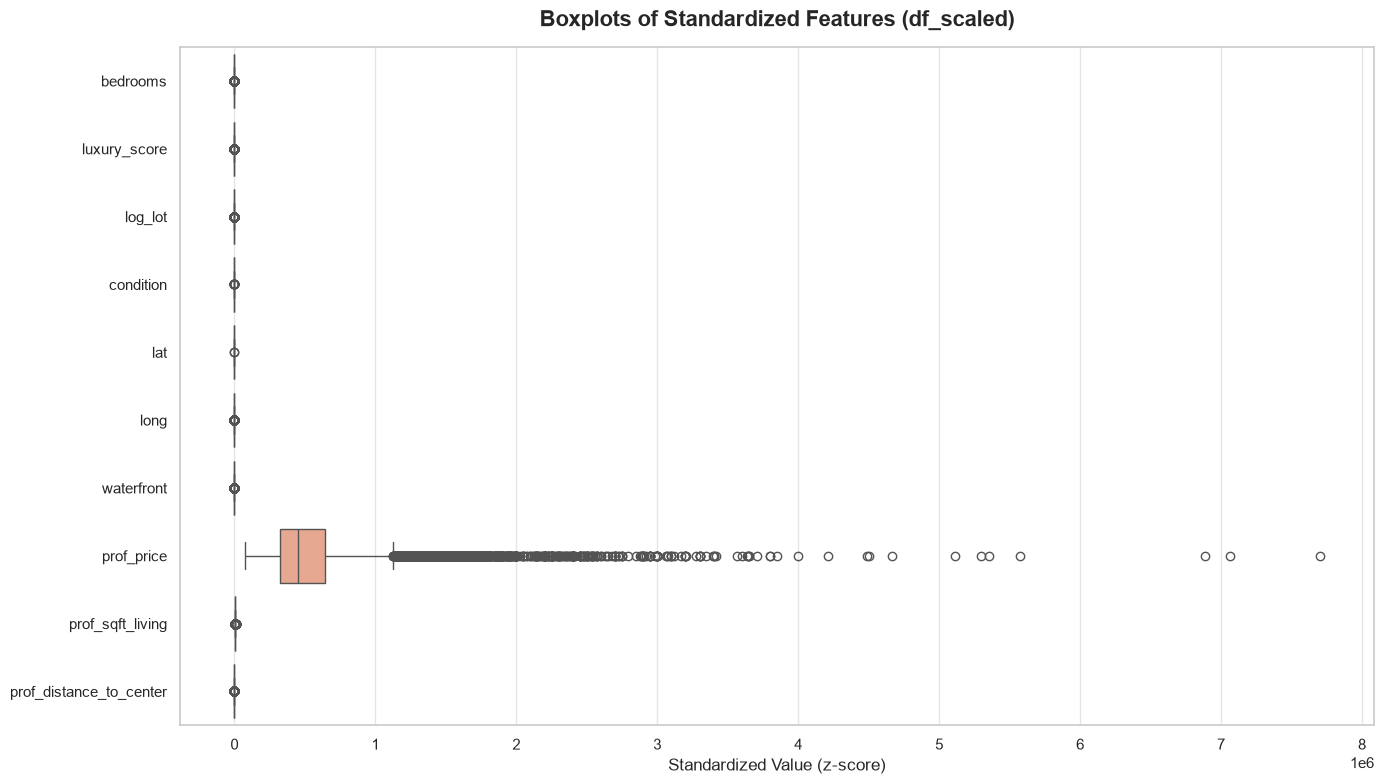

In [34]:
# Set a clean grid theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))
# Plot all Z-transformed features in a single horizontal plot to compare outliers/scales
sns.boxplot(data=df_scaled, orient="h", palette="coolwarm")
plt.title("Boxplots of Standardized Features (df_scaled)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Standardized Value (z-score)", fontsize=12)
plt.tight_layout()
plt.show()

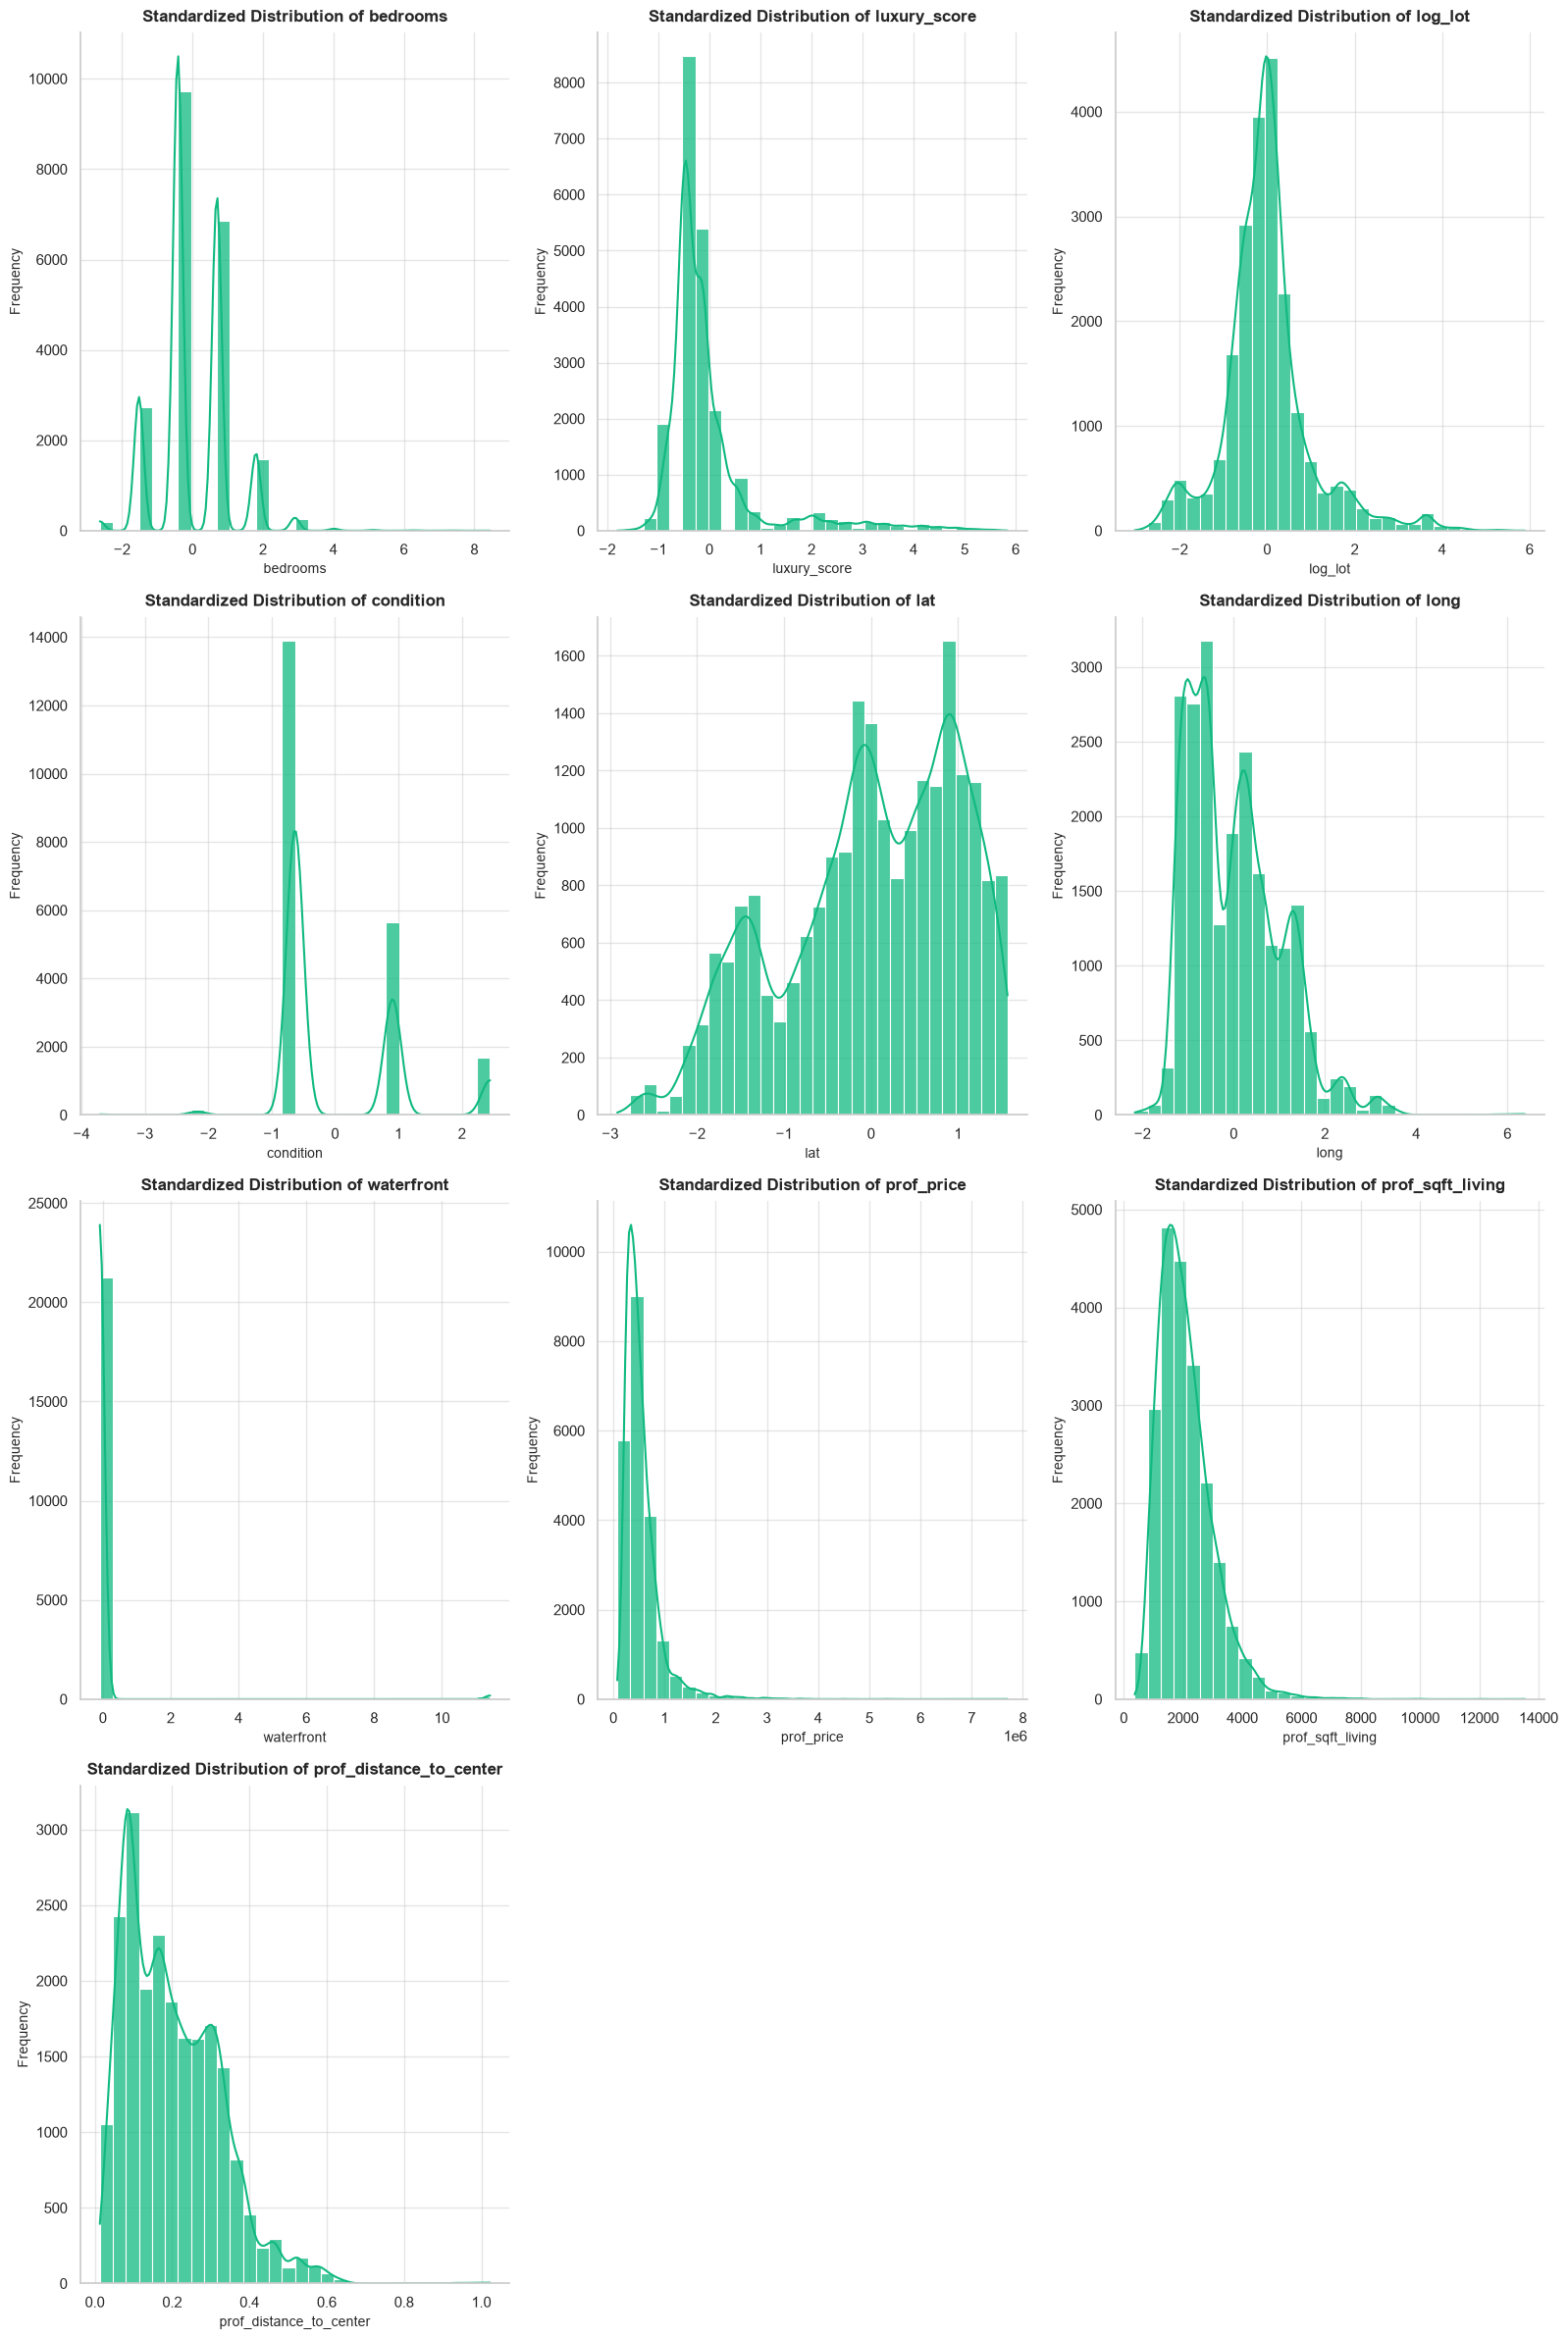

In [35]:
# Dynamisches Grid: Groesse richtet sich nach Anzahl der Spalten in df_scaled
ncols = 3
nrows = int(np.ceil(len(df_scaled.columns) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows))
axes = axes.flatten()

# Emerald green color to indicate the scaled/transformed state
plot_color = "#10B981"

# Plot a histogram for each standardized column
for i, col in enumerate(df_scaled.columns):
    sns.histplot(
        data=df_scaled, 
        x=col, 
        kde=True, 
        ax=axes[i], 
        color=plot_color, 
        bins=30, 
        edgecolor="white", 
        alpha=0.75
    )
    
    # Format the titles and labels
    axes[i].set_title(f'Standardized Distribution of {col}', fontsize=12, fontweight='bold', pad=8)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    
    # Clean up the borders
    sns.despine(ax=axes[i])

# Hide any unused subplot axes (safety net if column count changes)
for j in range(len(df_scaled.columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [36]:
# Save the standardized DataFrame to a CSV file in Meilenstein_3/David
# Repo-Root ueber den .git-Ordner finden -> funktioniert bei jedem, unabhaengig vom
# Speicherort des geklonten Repos oder dem Arbeitsverzeichnis des Kernels
from pathlib import Path

def find_repo_root(start):
    for parent in [start, *start.parents]:
        if (parent / ".git").exists():
            return parent
    return start  # Fallback, falls kein .git gefunden wird

repo_root = find_repo_root(Path.cwd())
output_dir = repo_root / "Meilenstein_3" / "David"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "cleaned_house_data_new.csv"
df_scaled.to_csv(output_path, index=False)

print(f"The clean preprocessed dataset has been saved as '{output_path}'!")
print("Clustering-Features:", final_features)
print("Profil-Spalten:", ['prof_' + c for c in profile_cols])


The clean preprocessed dataset has been saved as 'C:\Users\joshu\PycharmProjects\DDM_Meilensteine\Meilenstein_3\David\cleaned_house_data_new.csv'!
Clustering-Features: ['bedrooms', 'luxury_score', 'log_lot', 'condition', 'lat', 'long', 'waterfront']
Profil-Spalten: ['prof_price', 'prof_sqft_living', 'prof_distance_to_center']
